<h1 style="text-align: center;">Predicting NBA Game Outcomes Using Logistic Regression and Gradient Boosted Trees</h1>
<h5 style="text-align: center;"> STAT-587-001, Data Science I<br>
Winter 2026<br>
Group 4<br>
<br>
By Neal Kuperman & Bingtang Huang
</h5>

In [149]:
# IMPORTS AND SETUP

import sys
from pathlib import Path

try:
    # Works when running as a script
    _project_root = Path(__file__).resolve().parent.parent
except NameError:
    # Jupyter / IPython: fall back to current working directory
    _project_root = Path.cwd().resolve().parent  # notebook is in scripts/, project root is one level up
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))
    
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import joblib
from scripts.logistic_reg_models import (
    PLSTransformer,
    LogisticRegressor,
    PCALogisticRegressor,
    PLSLogisticRegressor,
    plot_roc_compare
)
import xgboost as xgb
from scripts.gradient_boosted_tree_models import train_xgboost
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance

from scipy import stats
import warnings
warnings.filterwarnings('ignore')


from source.db import get_engine
from scripts.get_data_from_db import *
from scripts.preprocessing import *

_data_dir = _project_root / "data"
_cleaned_data_dir = _project_root / "cleaned_data"
_plots_dir = _project_root / "figures"
_models_dir = _project_root / "models"

default_engine = get_engine()

RANDOM_STATE = 42

<h1 style="text-align:center; text-decoration:underline; margin-bottom:10px;">
Exploratory Data Analysis
</h1>

## Import Data

We will be using already cleaned data that was created by running scripts/preprocessing.py. The cleaned data CSV is located at cleaned_data/cleaned_data_2_21_26.csv. Some columns in the cleaned data will not be used in the EDA and modelings and must be removed before proceeding.

In [150]:
# Column Assigment

unneeded_columns=['team_name','opponent_name','opponent_pts',
 'team_box_id', 'game_id', 'team_id',
 'season_year', 'game_date', 'neutral_site',
 'opponent_team_id', 'game_number', 'pts',
 'fgm', 'fga', 'fg_pct', 'fg3m', 'fg3a', 'fg3_pct',
 'ftm', 'fta', 'ft_pct',
 'oreb', 'dreb', 'reb',
 'ast', 'tov', 'stl', 'blk', 'blka',
 'pf', 'pfd',
 'pace', 'poss', 'minutes_played',
 'total_wins', 'total_losses', 'diff_pts',
 'diff_ast', 'diff_tov', 'total_wins', 'total_losses',
 'diff_pts', 'diff_ast', 'diff_tov',
 'diff_blk', 'diff_blka', 'diff_fgm',
 'diff_fga', 'diff_ftm', 'diff_fta',
 'diff_pf', 'diff_pfd', 'diff_stl',
 'diff_oreb', 'diff_dreb', 'diff_fg3m',
 'diff_fg3a', 'diff_days_rest_average',
 'diff_days_rest_rolling_mean_prev_5',
 'diff_win_percentage_average',
 'diff_win_percentage_last_10_average',
 'diff_win_percentage_last_10_rolling_mean_prev_5',
 'diff_win_percentage_last_5_average',
 'diff_win_percentage_last_5_rolling_mean_prev_5',
 'diff_win_percentage_rolling_mean_prev_5',
 'diff_wins_last_10_average',
 'diff_wins_last_10_rolling_mean_prev_5',
 'diff_wins_last_5_average',
 'diff_wins_last_5_rolling_mean_prev_5',
 'diff_days_rest_rolling_mean_prev_10',
 'diff_win_percentage_last_10_rolling_mean_prev_10',
 'diff_wins_last_10_rolling_mean_prev_10',
 'diff_wins_last_5_rolling_mean_prev_10', 
 'Unnamed: 0'                ]

in_game_factors = [
    'win', 'pts', 'fgm', 'fga', 'fg_pct', 'fg3m', 'fg3a', 'fg3_pct', 'ftm', 'fta', 'ft_pct',
     'oreb', 'dreb', 'reb', 'ast', 'tov', 
    'stl', 'blk', 'blka', 'pf', 'pfd', 'pace', 'poss','days_rest', 'wins_last_10',
     'win_percentage', 'win_percentage_last_10',
    'is_home', 'is_back_to_back',
    'diff_win_percentage', 'diff_win_percentage_last_10',
    'diff_wins_last_10',  'diff_days_rest',
    'ast_average', 'blk_average', 'blka_average', 'dreb_average', 'fg3a_average',
    'fg3m_average', 'fga_average', 'fgm_average', 'fta_average', 'ftm_average',
    'oreb_average', 'pace_average', 'pf_average', 'pfd_average', 'pts_average',
    'reb_average', 'stl_average', 'tov_average',
    'diff_ast_average', 'diff_blk_average', 'diff_blka_average', 'diff_dreb_average',
    'diff_fg3a_average', 'diff_fg3m_average', 'diff_fga_average', 'diff_fgm_average',
    'diff_fta_average', 'diff_ftm_average', 'diff_oreb_average', 'diff_pace_average',
    'diff_pf_average', 'diff_pfd_average', 'diff_pts_average', 'diff_stl_average',
    'diff_tov_average',
    'ast_rolling_mean_prev_10', 'blk_rolling_mean_prev_10', 'blka_rolling_mean_prev_10',
    'dreb_rolling_mean_prev_10', 'fg3a_rolling_mean_prev_10', 'fg3m_rolling_mean_prev_10',
    'fga_rolling_mean_prev_10', 'fgm_rolling_mean_prev_10', 'fta_rolling_mean_prev_10',
    'ftm_rolling_mean_prev_10', 'oreb_rolling_mean_prev_10', 'pace_rolling_mean_prev_10',
    'pf_rolling_mean_prev_10', 'pfd_rolling_mean_prev_10', 'pts_rolling_mean_prev_10',
    'reb_rolling_mean_prev_10', 'stl_rolling_mean_prev_10', 'tov_rolling_mean_prev_10',
    'diff_ast_rolling_mean_prev_10', 'diff_blk_rolling_mean_prev_10', 'diff_blka_rolling_mean_prev_10',
    'diff_dreb_rolling_mean_prev_10', 'diff_fg3a_rolling_mean_prev_10', 'diff_fg3m_rolling_mean_prev_10',
    'diff_fga_rolling_mean_prev_10', 'diff_fgm_rolling_mean_prev_10', 'diff_fta_rolling_mean_prev_10',
    'diff_ftm_rolling_mean_prev_10', 'diff_oreb_rolling_mean_prev_10', 'diff_pace_rolling_mean_prev_10',
    'diff_pf_rolling_mean_prev_10', 'diff_pfd_rolling_mean_prev_10', 'diff_pts_rolling_mean_prev_10',
    'diff_stl_rolling_mean_prev_10', 'diff_tov_rolling_mean_prev_10'
]

In [151]:
# Import Data and create in game dataframe
clean_data_df=pd.read_csv("../cleaned_data/cleaned_data_2_21_26.csv")
in_game_df = clean_data_df[in_game_factors]


In [152]:
# HOME vs AWAY Performance
print("="*80)
print("HOME VS AWAY ANALYSIS")
print("="*80)

home_win_pct = in_game_df[in_game_df['is_home'] == 1]['win'].mean()
away_win_pct = in_game_df[in_game_df['is_home'] == 0]['win'].mean()

print(f"Home win %: {home_win_pct:.2%}")
print(f"Away win %: {away_win_pct:.2%}")
print(f"Home advantage: +{(home_win_pct - away_win_pct)*100:.1f}%")

HOME VS AWAY ANALYSIS
Home win %: 55.11%
Away win %: 44.92%
Home advantage: +10.2%


### Set visualization style

In [153]:
# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Convert win to binary if needed
if in_game_df['win'].dtype == bool:
    in_game_df['win'] = in_game_df['win'].astype(int)

### Statistical Summary by Win/Loss

In [154]:
##  Statistical Summary by Win/Loss 
print("\n" + "="*80)
print("STATISTICAL SUMMARY BY WIN/LOSS")
print("="*80)

# Split data by win/loss
wins = in_game_df[in_game_df['win'] == 1]
losses = in_game_df[in_game_df['win'] == 0]

# Select numeric columns for comparison
numeric_cols = in_game_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('win')

# Create comparison dataframe
comparison_stats = pd.DataFrame({
    'Wins_Mean': wins[numeric_cols].mean(),
    'Wins_Std': wins[numeric_cols].std(),
    'Losses_Mean': losses[numeric_cols].mean(),
    'Losses_Std': losses[numeric_cols].std(),
    'Difference': wins[numeric_cols].mean() - losses[numeric_cols].mean(),
    'Diff_Percent': ((wins[numeric_cols].mean() - losses[numeric_cols].mean()) / losses[numeric_cols].mean().abs()) * 100
})

# Add t-test p-values
p_values = []
for col in numeric_cols:
    if wins[col].notna().sum() > 0 and losses[col].notna().sum() > 0:
        t_stat, p_val = stats.ttest_ind(wins[col].dropna(), losses[col].dropna())
        p_values.append(p_val)
    else:
        p_values.append(np.nan)

comparison_stats['P_Value'] = p_values
comparison_stats['Significant'] = comparison_stats['P_Value'] < 0.05

# Sort by absolute difference
comparison_stats = comparison_stats.sort_values('Difference', key=abs, ascending=False)

print("\nTop features that differentiate wins from losses:")
print(comparison_stats.head(20).round(4))


STATISTICAL SUMMARY BY WIN/LOSS

Top features that differentiate wins from losses:
                               Wins_Mean  Wins_Std  Losses_Mean  Losses_Std  \
pts                             119.5221   11.0176     107.2606     11.1315   
fgm                              43.7411    4.8630      39.4139      4.7127   
dreb                             35.3381    5.1589      31.3587      4.8672   
reb                              45.8711    6.4458      41.9954      6.2290   
diff_pts_average                  1.8002    5.1735      -1.7910      5.4871   
ast                              27.3534    5.1281      24.1281      4.6423   
diff_pts_rolling_mean_prev_10     1.2865    6.5149      -1.2888      6.7963   
fg3m                             13.9054    4.0000      11.7711      3.5366   
pts_average                     113.8099    4.8796     112.0919      4.9393   
ftm                              18.1346    6.0757      16.6617      5.5479   
diff_wins_last_10                 0.7000    2.7

### Correlation Analysis


CORRELATION WITH WIN

Features most positively correlated with winning:
pts                    0.4844
diff_win_percentage    0.4586
fg_pct                 0.4574
fgm                    0.4118
dreb                   0.3688
fg3_pct                0.3575
win_percentage         0.3476
diff_pts_average       0.3191
ast                    0.3131
reb                    0.2924
Name: win, dtype: float64

Features most negatively correlated with winning:
diff_tov_rolling_mean_prev_10    -0.0747
diff_blka_rolling_mean_prev_10   -0.0821
tov_rolling_mean_prev_10         -0.0837
tov                              -0.0927
blka_rolling_mean_prev_10        -0.1036
diff_tov_average                 -0.1045
tov_average                      -0.1064
diff_blka_average                -0.1309
blka_average                     -0.1406
blka                             -0.1529
Name: win, dtype: float64


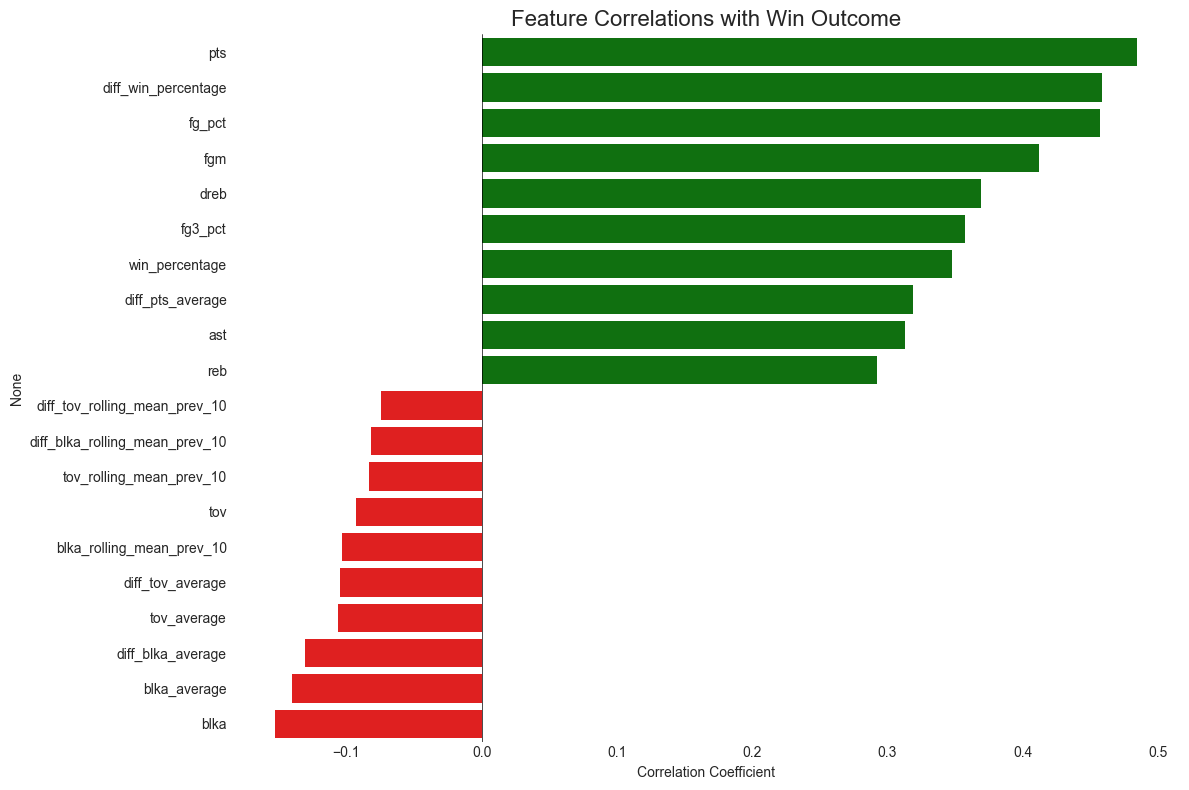

In [155]:
# Correlation Analysis
print("\n" + "="*80)
print("CORRELATION WITH WIN")
print("="*80)

correlations = in_game_df[numeric_cols + ['win']].corr()['win'].sort_values(ascending=False)
print("\nFeatures most positively correlated with winning:")
print(correlations.head(11)[1:].round(4))  # Skip win itself

print("\nFeatures most negatively correlated with winning:")
print(correlations.tail(10).round(4))

# Visualize top correlations
fig, ax = plt.subplots(figsize=(12, 8))  # Get figure and axes objects

# Set transparent backgrounds
fig.patch.set_alpha(0)   # Figure background transparent
ax.patch.set_alpha(0)    # Axes background transparent

top_corr = pd.concat([correlations.head(11)[1:], correlations.tail(10)])
colors = ['green' if x > 0 else 'red' for x in top_corr.values]
sns.barplot(x=top_corr.values, y=top_corr.index, palette=colors, ax=ax)
ax.set_title('Feature Correlations with Win Outcome', fontsize=16)
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()

# Save with transparency
plt.savefig('correlation_-bar_plot.png', transparent=True)

plt.show()



### Correlation Heatmap (for top features)


CORRELATION HEATMAP - TOP FEATURES


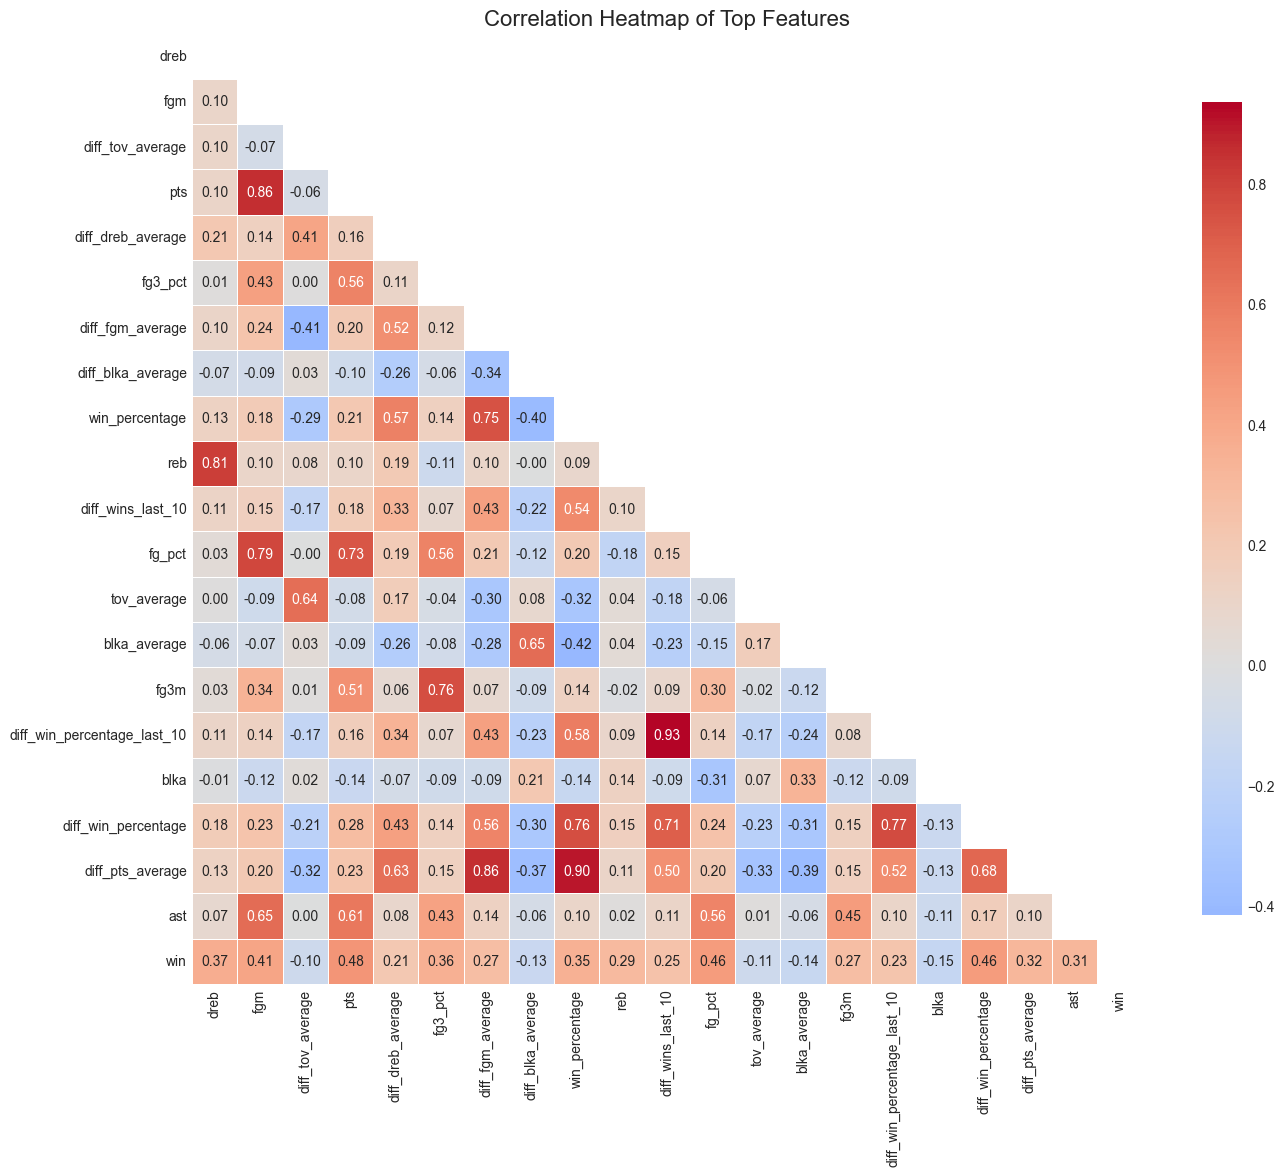

In [156]:
# Correlation Heatmap (for top features)
print("\n" + "="*80)
print("CORRELATION HEATMAP - TOP FEATURES")
print("="*80)

# Select top features based on correlation with win
top_features = correlations.head(16)[1:].index.tolist() + correlations.tail(5).index.tolist()
top_features = list(set(top_features))  # Remove duplicates

# Create figure with explicit reference
fig = plt.figure(figsize=(14, 12))
fig.patch.set_alpha(0)  # Make figure background transparent

# Compute correlation matrix and mask
corr_matrix = in_game_df[top_features + ['win']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw heatmap and get axes
ax = sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                 cmap='coolwarm', center=0, square=True,
                 linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.patch.set_alpha(0)  # Make axes background transparent

# Add title
plt.title('Correlation Heatmap of Top Features', fontsize=16)
plt.tight_layout()

# To save with transparency
plt.savefig(_plots_dir / 'heatmap.png', transparent=True)

plt.show()


### OUTLIER ANALYSIS WITH BOX PLOTS

In [157]:
print("="*80)
print("OUTLIER ANALYSIS WITH BOX PLOTS")
print("="*80)

# Select key statistics for outlier analysis
key_stats = ['pts', 'fgm', 'fga', 'fg_pct', 'fg3m', 'fg3a', 'fg3_pct', 'ftm', 'fta', 'ft_pct', 'oreb', 'dreb', 'reb', 'ast', 'tov', 
 'stl', 'blk', 'blka', 'pf', 'pfd', 'pace', 'poss','days_rest']
available_stats = [stat for stat in key_stats if stat in in_game_df.columns]

print(f"\nAnalyzing {len(available_stats)} key statistics")

# 1. Function to detect outliers using IQR method
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# 2. Function to detect outliers using Z-score method
def detect_outliers_zscore(df, column, threshold=3):
    z_scores = np.abs(stats.zscore(df[column].dropna()))
    outliers = df.iloc[np.where(z_scores > threshold)[0]]
    return outliers

# 3. Create comprehensive outlier analysis
print("\n" + "="*80)
print("OUTLIER DETECTION RESULTS")
print("="*80)

outlier_summary = []

for stat in available_stats:
    # IQR method
    outliers_iqr, lower, upper = detect_outliers_iqr(in_game_df, stat)
    
    # Z-score method
    outliers_zscore = detect_outliers_zscore(in_game_df, stat)
    
    # Calculate statistics
    stat_mean = in_game_df[stat].mean()
    stat_std = in_game_df[stat].std()
    stat_min = in_game_df[stat].min()
    stat_max = in_game_df[stat].max()
    
    # Store summary
    outlier_summary.append({
        'Statistic': stat,
        'Mean': stat_mean,
        'Std': stat_std,
        'Min': stat_min,
        'Max': stat_max,
        'IQR_Outliers': len(outliers_iqr),
        'IQR_Outlier_%': (len(outliers_iqr) / len(in_game_df)) * 100,
        'ZScore_Outliers': len(outliers_zscore),
        'ZScore_Outlier_%': (len(outliers_zscore) / len(in_game_df)) * 100,
        'Lower_Bound': lower,
        'Upper_Bound': upper
    })
    
    # Print significant findings
    if len(outliers_iqr) > 0:
        print(f"\n📊 {stat.upper()} - Outliers found:")
        print(f"   Range: {stat_min:.2f} to {stat_max:.2f}")
        print(f"   Mean: {stat_mean:.2f} ± {stat_std:.2f}")
        print(f"   IQR outliers: {len(outliers_iqr)} ({len(outliers_iqr)/len(in_game_df)*100:.2f}%)")
        print(f"   Normal range: [{lower:.2f}, {upper:.2f}]")
        
        # Check if outliers are more likely to be wins
        if len(outliers_iqr) > 0:
            outlier_win_rate = outliers_iqr['win'].mean()
            normal_data = in_game_df[~in_game_df.index.isin(outliers_iqr.index)]
            normal_win_rate = normal_data['win'].mean()
            print(f"   Outlier win rate: {outlier_win_rate:.2%}")
            print(f"   Normal win rate: {normal_win_rate:.2%}")
            print(f"   Impact: {(outlier_win_rate - normal_win_rate)*100:+.1f}%")


OUTLIER ANALYSIS WITH BOX PLOTS

Analyzing 23 key statistics

OUTLIER DETECTION RESULTS

📊 PTS - Outliers found:
   Range: 66.00 to 176.00
   Mean: 113.39 ± 12.66
   IQR outliers: 87 (0.65%)
   Normal range: [79.50, 147.50]
   Outlier win rate: 55.17%
   Normal win rate: 49.97%
   Impact: +5.2%

📊 FGM - Outliers found:
   Range: 22.00 to 65.00
   Mean: 41.58 ± 5.25
   IQR outliers: 102 (0.76%)
   Normal range: [27.50, 55.50]
   Outlier win rate: 70.59%
   Normal win rate: 49.85%
   Impact: +20.7%

📊 FGA - Outliers found:
   Range: 64.00 to 122.00
   Mean: 88.64 ± 7.08
   IQR outliers: 199 (1.48%)
   Normal range: [70.50, 106.50]
   Outlier win rate: 42.71%
   Normal win rate: 50.12%
   Impact: -7.4%

📊 FG_PCT - Outliers found:
   Range: 0.28 to 0.69
   Mean: 0.47 ± 0.05
   IQR outliers: 77 (0.57%)
   Normal range: [0.32, 0.62]
   Outlier win rate: 70.13%
   Normal win rate: 49.89%
   Impact: +20.2%

📊 FG3M - Outliers found:
   Range: 2.00 to 29.00
   Mean: 12.84 ± 3.92
   IQR outliers:

### Create Outlier summary dataframe

In [158]:
# Create summary dataframe
outlier_df = pd.DataFrame(outlier_summary)
print("\n" + "="*80)
print("OUTLIER SUMMARY TABLE")
print("="*80)
print(outlier_df.round(2).to_string(index=False))


OUTLIER SUMMARY TABLE
Statistic   Mean   Std   Min    Max  IQR_Outliers  IQR_Outlier_%  ZScore_Outliers  ZScore_Outlier_%  Lower_Bound  Upper_Bound
      pts 113.39 12.66 66.00 176.00            87           0.65               37              0.28        79.50       147.50
      fgm  41.58  5.25 22.00  65.00           102           0.76               35              0.26        27.50        55.50
      fga  88.64  7.08 64.00 122.00           199           1.48               77              0.57        70.50       106.50
   fg_pct   0.47  0.05  0.28   0.69            77           0.57               41              0.31         0.32         0.62
     fg3m  12.84  3.92  2.00  29.00           178           1.33               52              0.39         2.50        22.50
     fg3a  35.55  6.96 10.00  65.00           137           1.02               40              0.30        17.50        53.50
  fg3_pct   0.36  0.08  0.07   0.68           113           0.84               38              

### Count outliers above and below the box for poss

In [159]:
def count_outliers(df, column, group_col=None, group_value=None):
    """
    Count outliers above and below the box for a given column.
    Outliers defined as values > Q3 + 1.5*IQR or < Q1 - 1.5*IQR.
    """
    if group_col is not None and group_value is not None:
        data = df[df[group_col] == group_value][column].dropna()
    else:
        data = df[column].dropna()
    
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    below = (data < lower_bound).sum()
    above = (data > upper_bound).sum()
    total_outliers = below + above
    
    return {
        'total': len(data),
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outliers_below': below,
        'outliers_above': above,
        'total_outliers': total_outliers,
        'outlier_percentage': (total_outliers / len(data)) * 100
    }

# Usage for 'poss' column
print("Overall poss outliers:")
overall = count_outliers(in_game_df, 'poss')
print(f"Total observations: {overall['total']}")
print(f"Outliers below: {overall['outliers_below']}")
print(f"Outliers above: {overall['outliers_above']}")
print(f"Total outliers: {overall['total_outliers']} ({overall['outlier_percentage']:.2f}%)")


Overall poss outliers:
Total observations: 13416
Outliers below: 44
Outliers above: 258
Total outliers: 302 (2.25%)


### Create Outlier box plots for all key statistics


CREATING BOX PLOTS


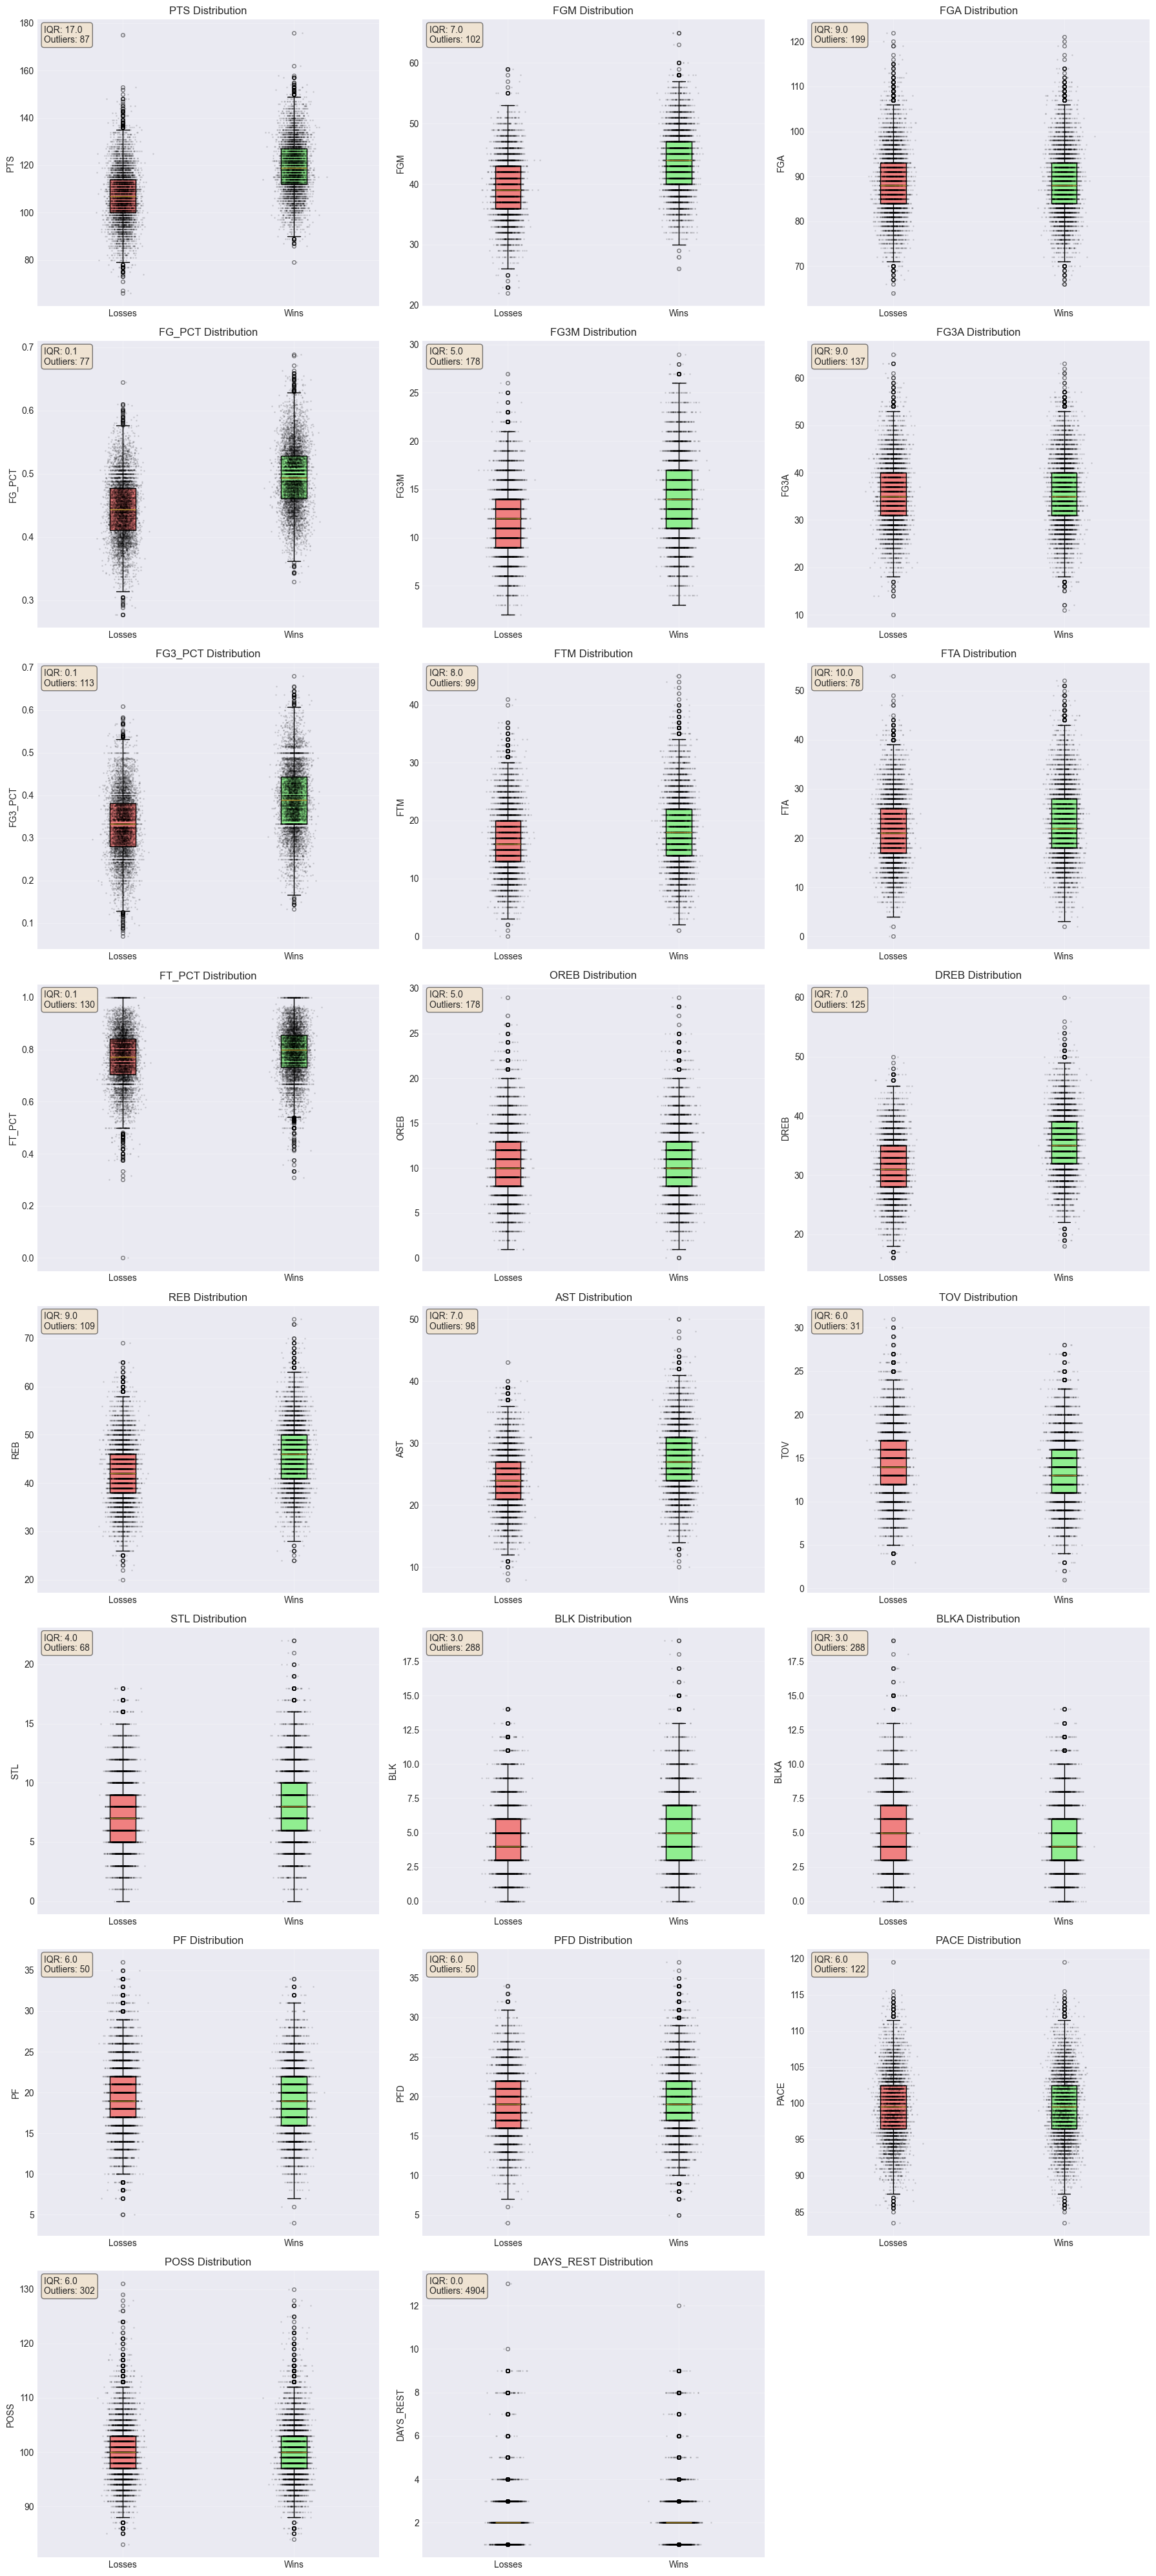

In [160]:
# Create box plots for all key statistics
print("\n" + "="*80)
print("CREATING BOX PLOTS")
print("="*80)

# Determine grid size for subplots
n_stats = len(available_stats)
n_cols = 3
n_rows = (n_stats + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))


# Flatten axes array for easy iteration
if n_rows > 1:
    axes = axes.flatten()
else:
    axes = [axes] if n_cols == 1 else axes

# Create box plots
for idx, stat in enumerate(available_stats):
    if idx < len(axes):
        # Create box plot split by win/loss
        data_to_plot = [
            in_game_df[in_game_df['win'] == 0][stat].dropna(),
            in_game_df[in_game_df['win'] == 1][stat].dropna()
        ]
        
        bp = axes[idx].boxplot(data_to_plot, labels=['Losses', 'Wins'], 
                               patch_artist=True, showfliers=True)
        
        # Color the boxes
        bp['boxes'][0].set_facecolor('lightcoral')
        bp['boxes'][1].set_facecolor('lightgreen')
        
        # Color the outliers
        for flier in bp['fliers']:
            flier.set(marker='o', markersize=4, alpha=0.5)
        
        # Add individual points (jittered) for better visualization
        for i, data in enumerate(data_to_plot):
            y = data
            x = np.random.normal(i+1, 0.04, size=len(y))
            axes[idx].plot(x, y, 'k.', alpha=0.1, markersize=2)
        
        # Add statistics as text
        q1 = in_game_df[stat].quantile(0.25)
        q3 = in_game_df[stat].quantile(0.75)
        iqr = q3 - q1
        axes[idx].text(0.02, 0.98, f'IQR: {iqr:.1f}\nOutliers: {outlier_df.iloc[idx]["IQR_Outliers"]:.0f}', 
                      transform=axes[idx].transAxes, verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        axes[idx].set_title(f'{stat.upper()} Distribution', fontsize=12)
        axes[idx].set_ylabel(stat.upper())
        axes[idx].grid(True, alpha=0.3)

# Hide empty subplots
for idx in range(len(available_stats), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# Select the last 5 statistics and save the figure with transparency

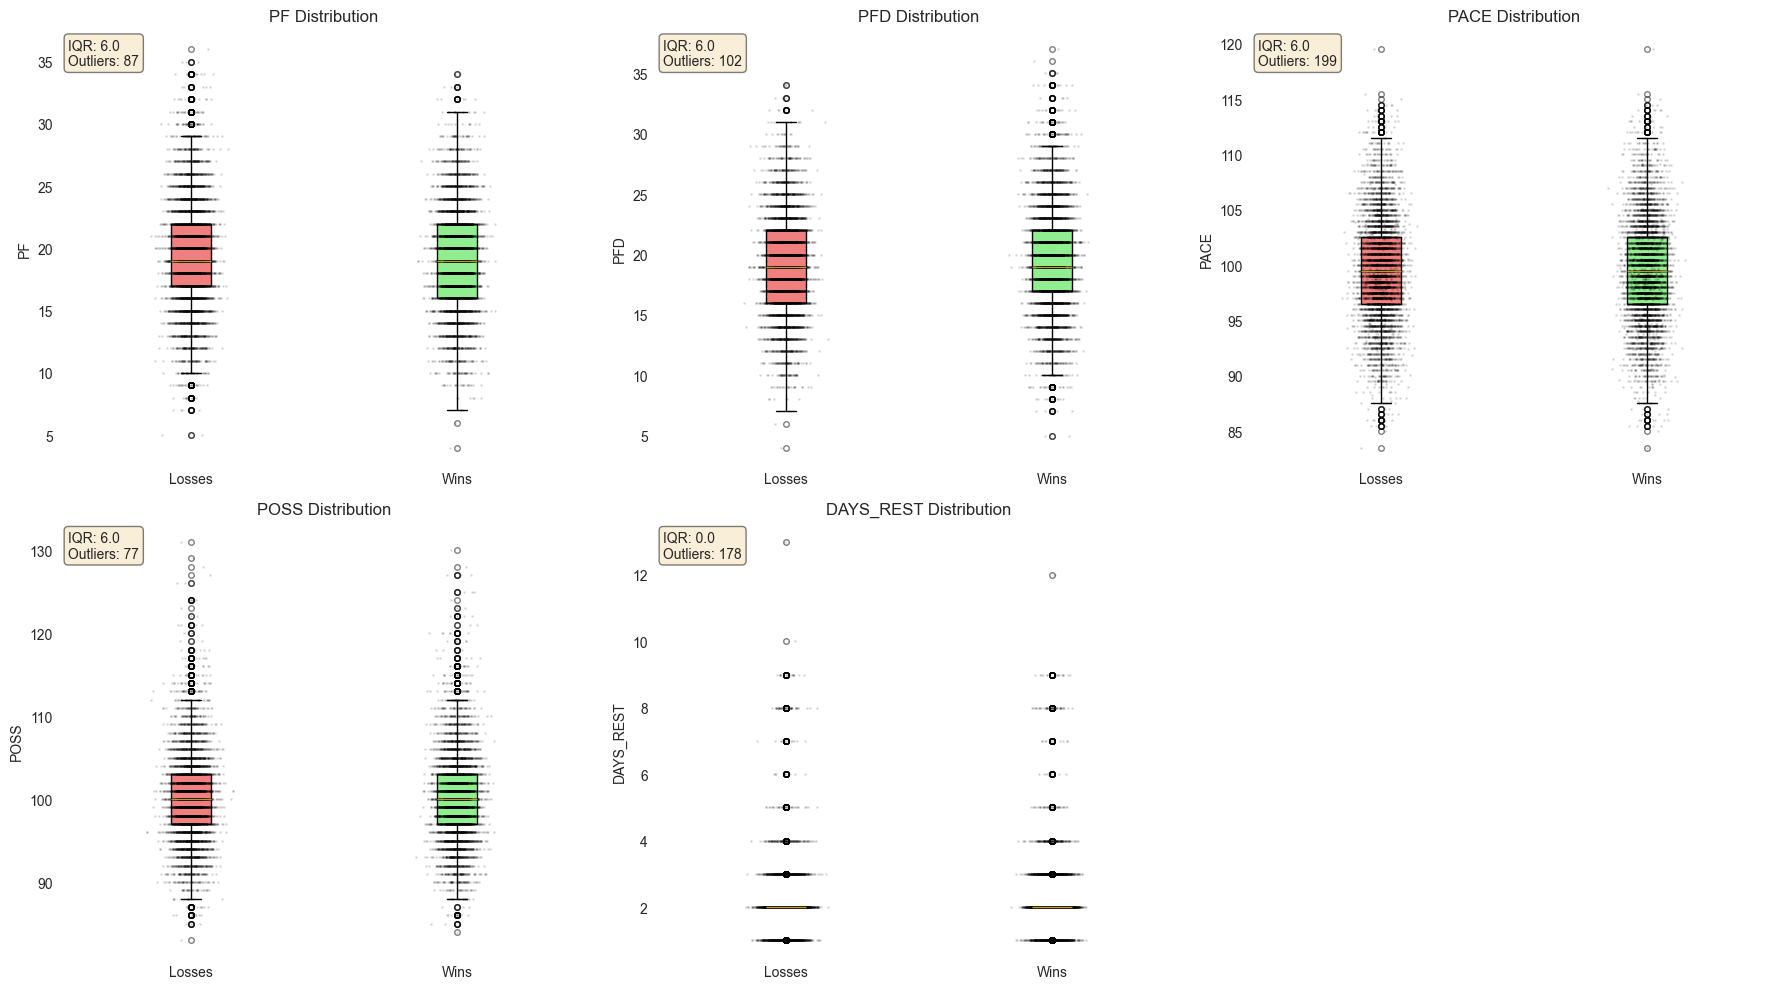

In [161]:
# Select the last 5 statistics
last_five_stats = available_stats[-5:]  # Adjust if you need a different selection

# Determine grid size for subplots
n_stats = len(last_five_stats)
n_cols = 3
n_rows = (n_stats + n_cols - 1) // n_cols

# Create figure with transparency
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
fig.patch.set_alpha(0)  # Make figure background transparent

# Flatten axes array for easy iteration
if n_rows > 1:
    axes = axes.flatten()
else:
    axes = [axes] if n_cols == 1 else axes

# Create box plots for each selected statistic
for idx, stat in enumerate(last_five_stats):
    if idx < len(axes):
        # Prepare data split by win/loss
        data_to_plot = [
            in_game_df[in_game_df['win'] == 0][stat].dropna(),
            in_game_df[in_game_df['win'] == 1][stat].dropna()
        ]
        
        # Create boxplot with transparent axes background
        bp = axes[idx].boxplot(data_to_plot, labels=['Losses', 'Wins'], 
                               patch_artist=True, showfliers=True)
        
        # Set box colors
        bp['boxes'][0].set_facecolor('lightcoral')
        bp['boxes'][1].set_facecolor('lightgreen')
        
        # Style outliers
        for flier in bp['fliers']:
            flier.set(marker='o', markersize=4, alpha=0.5)
        
        # Add jittered individual points
        for i, data in enumerate(data_to_plot):
            y = data
            x = np.random.normal(i+1, 0.04, size=len(y))
            axes[idx].plot(x, y, 'k.', alpha=0.1, markersize=2)
        
        # Add statistics text box
        q1 = in_game_df[stat].quantile(0.25)
        q3 = in_game_df[stat].quantile(0.75)
        iqr = q3 - q1
        # outlier_df should be defined previously; if not, adjust or remove
        axes[idx].text(0.02, 0.98, f'IQR: {iqr:.1f}\nOutliers: {outlier_df.iloc[idx]["IQR_Outliers"]:.0f}', 
                      transform=axes[idx].transAxes, verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        axes[idx].set_title(f'{stat.upper()} Distribution', fontsize=12)
        axes[idx].set_ylabel(stat.upper())
        axes[idx].grid(True, alpha=0.3)
        
        # Make each subplot's background transparent
        axes[idx].patch.set_alpha(0)

# Hide any empty subplots
for idx in range(len(last_five_stats), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()

# Save the figure with transparency
plt.savefig(_plots_dir / 'last_five_outlier_boxplots.png', transparent=True)

plt.show()

###  Separate box plots for differential stats


BOX PLOTS: DIFFERENTIAL STATISTICS


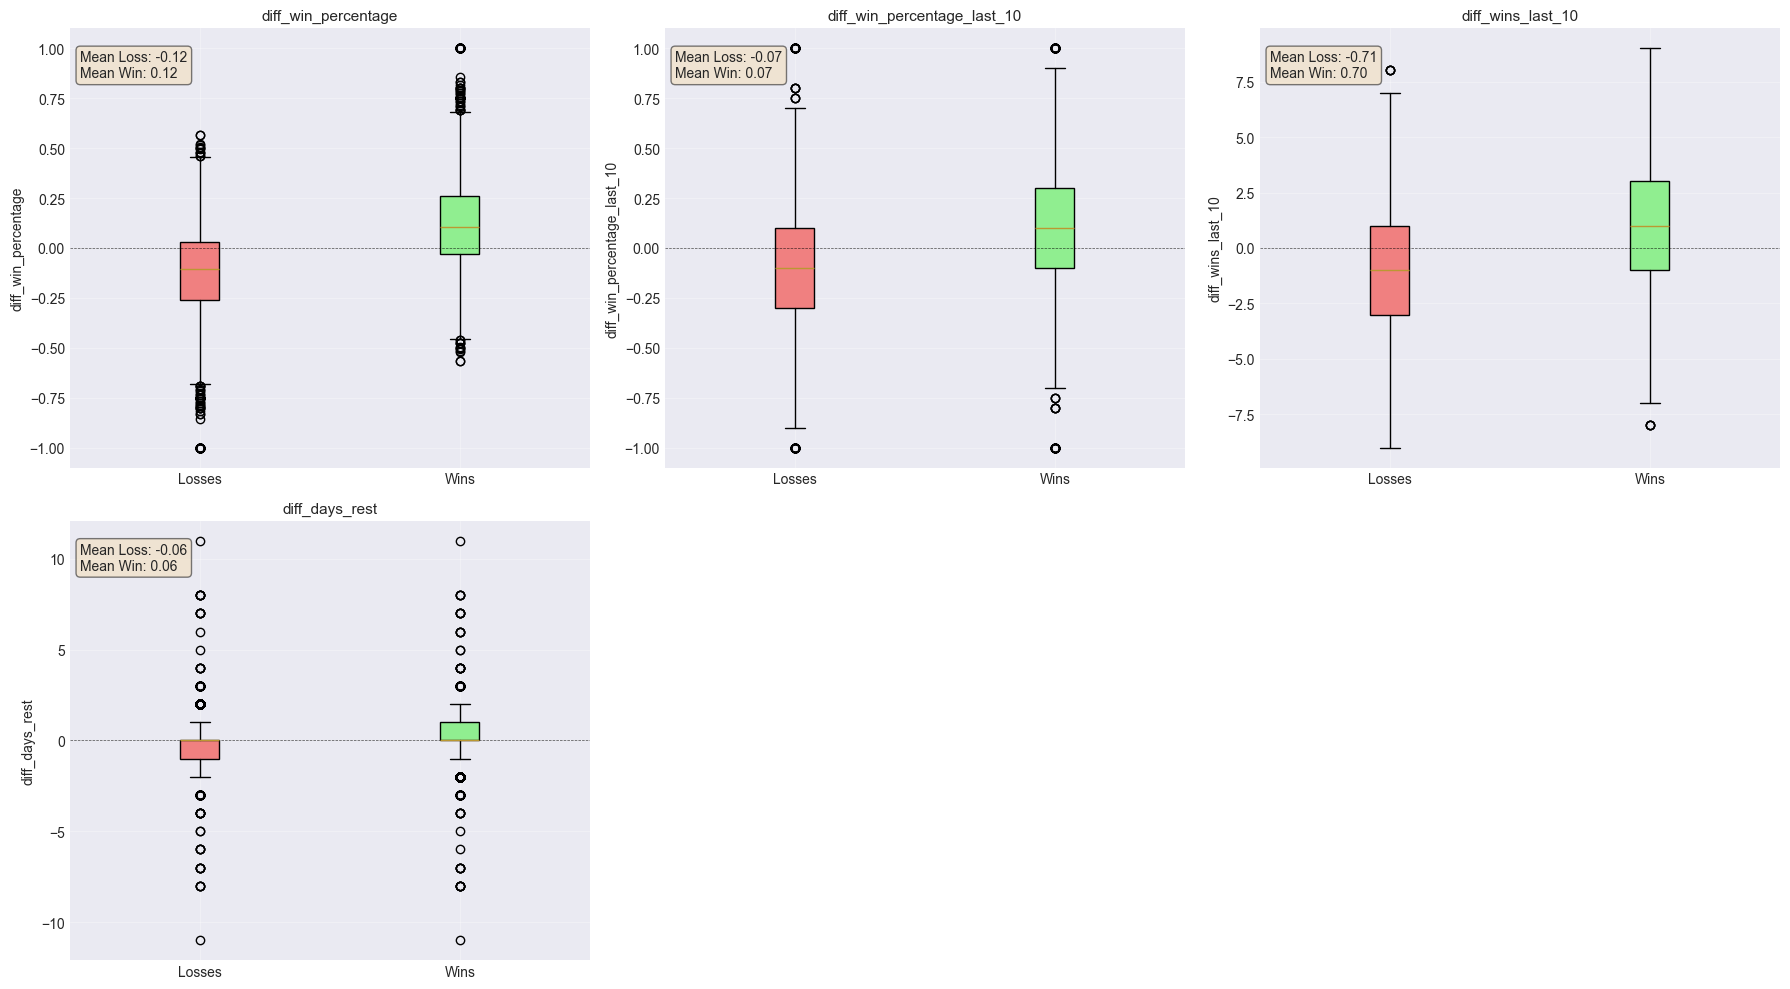

In [162]:
#  Separate box plots for differential stats
print("\n" + "="*80)
print("BOX PLOTS: DIFFERENTIAL STATISTICS")
print("="*80)

diff_stats = [col for col in in_game_df.columns if col.startswith('diff_') and 'average' not in col and 'rolling' not in col]

if diff_stats:
    n_diff = len(diff_stats)
    n_rows = (n_diff + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5*n_rows))
    
    
    if n_rows > 1:
        axes = axes.flatten()
    
    for idx, stat in enumerate(diff_stats):
        if idx < len(axes):
            data_to_plot = [
                in_game_df[in_game_df['win'] == 0][stat].dropna(),
                in_game_df[in_game_df['win'] == 1][stat].dropna()
            ]
            
            bp = axes[idx].boxplot(data_to_plot, labels=['Losses', 'Wins'],
                                   patch_artist=True, showfliers=True)
            
            bp['boxes'][0].set_facecolor('lightcoral')
            bp['boxes'][1].set_facecolor('lightgreen')
            
            # Add horizontal line at zero
            axes[idx].axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.7)
            
            # Add mean values
            mean_loss = in_game_df[in_game_df['win'] == 0][stat].mean()
            mean_win = in_game_df[in_game_df['win'] == 1][stat].mean()
            axes[idx].text(0.02, 0.95, f'Mean Loss: {mean_loss:.2f}\nMean Win: {mean_win:.2f}',
                          transform=axes[idx].transAxes, verticalalignment='top',
                          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
            axes[idx].set_title(f'{stat}', fontsize=11)
            axes[idx].set_ylabel(stat)
            axes[idx].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(diff_stats), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

###  Rolling stats box plots

In [163]:
#  Rolling stats box plots
print("\n" + "="*80)
print("BOX PLOTS: ROLLING AVERAGES")
print("="*80)

rolling_stats = [col for col in in_game_df.columns if 'rolling_mean_prev_5' in col]

if rolling_stats:
    n_rolling = len(rolling_stats)
    n_rows = (n_rolling + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5*n_rows))
    
    
    if n_rows > 1:
        axes = axes.flatten()
    
    for idx, stat in enumerate(rolling_stats):
        if idx < len(axes):
            data_to_plot = [
                in_game_df[in_game_df['win'] == 0][stat].dropna(),
                in_game_df[in_game_df['win'] == 1][stat].dropna()
            ]
            
            bp = axes[idx].boxplot(data_to_plot, labels=['Losses', 'Wins'],
                                   patch_artist=True, showfliers=True)
            
            bp['boxes'][0].set_facecolor('lightcoral')
            bp['boxes'][1].set_facecolor('lightgreen')
            
            short_name = stat.replace('_rolling_mean_prev_5', '')
            axes[idx].set_title(f'{short_name} (5-game avg)', fontsize=11)
            axes[idx].set_ylabel(short_name)
            axes[idx].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(rolling_stats), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()


BOX PLOTS: ROLLING AVERAGES


### POINTS ANALYSIS


POINTS ANALYSIS

📊 Basic Points Statistics:
Average points per game: 113.39
Median points: 113.00
Std deviation: 12.66
Min points: 66.00
Max points: 176.00

📈 Points by Game Outcome:
Winning teams average: 119.52
Losing teams average: 107.26
Difference: 12.26


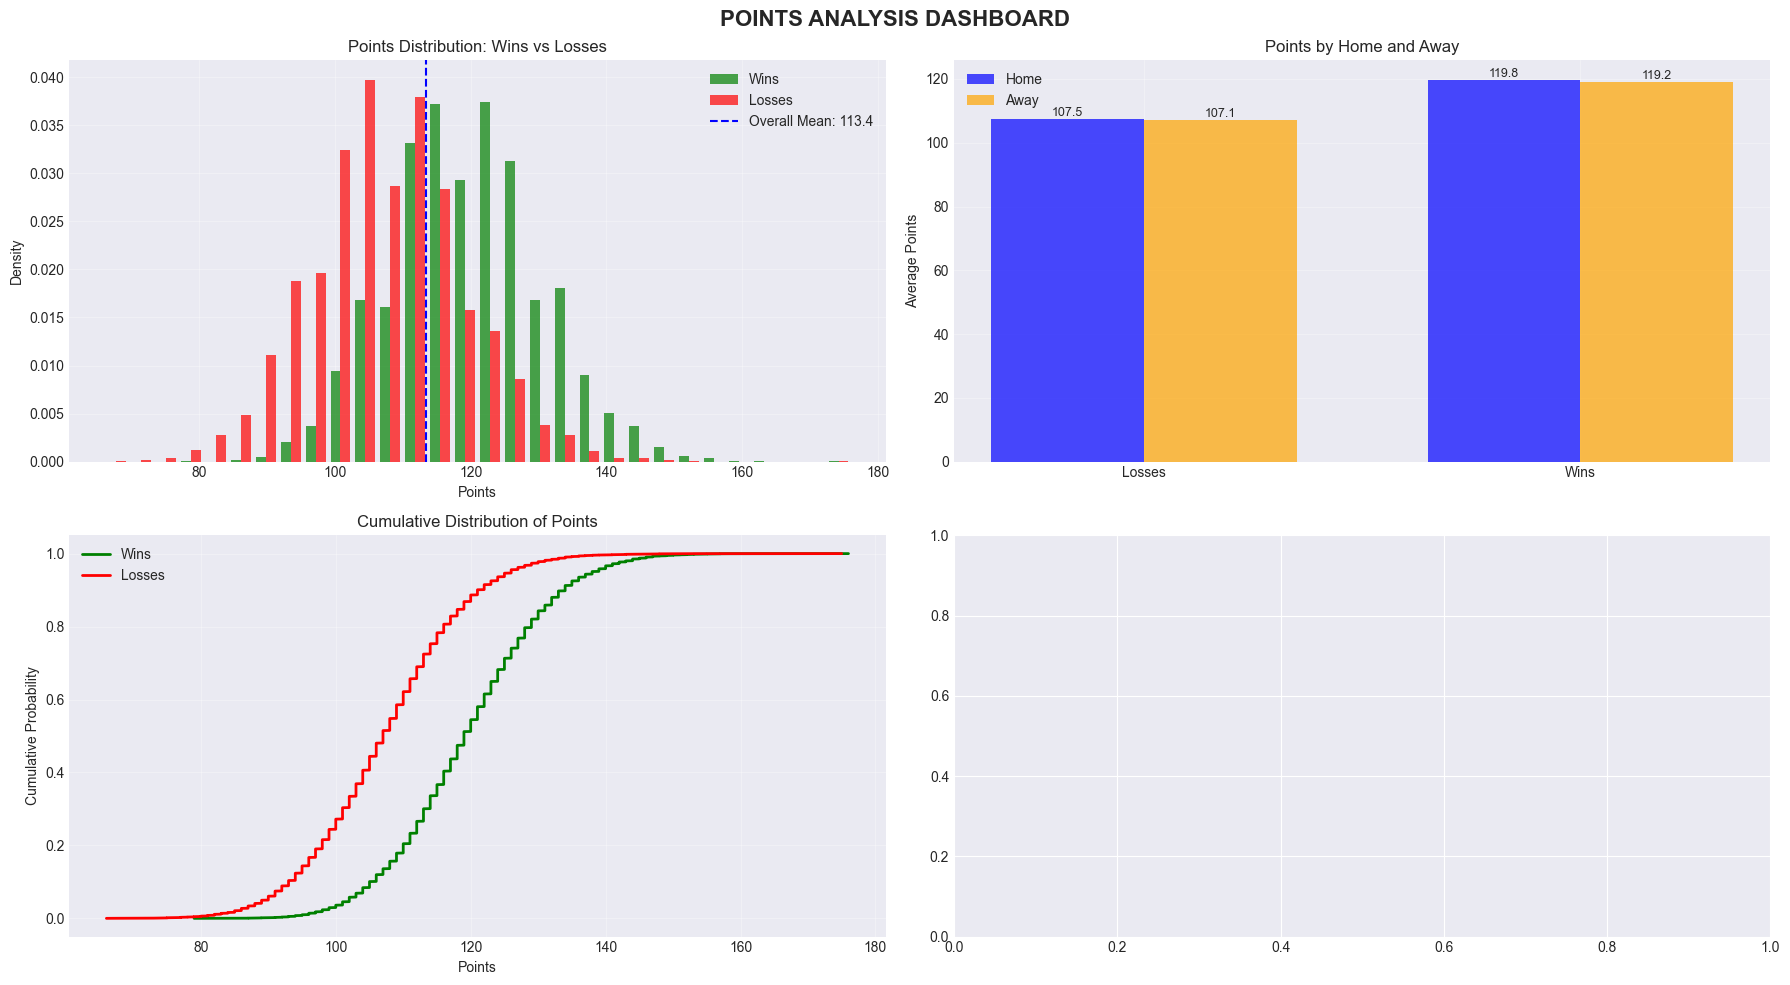

In [164]:
# POINTS ANALYSIS

print("\n" + "="*80)
print("POINTS ANALYSIS")
print("="*80)

# Basic points statistics
print("\n📊 Basic Points Statistics:")
print(f"Average points per game: {in_game_df['pts'].mean():.2f}")
print(f"Median points: {in_game_df['pts'].median():.2f}")
print(f"Std deviation: {in_game_df['pts'].std():.2f}")
print(f"Min points: {in_game_df['pts'].min():.2f}")
print(f"Max points: {in_game_df['pts'].max():.2f}")

# Points by game outcome
print("\n📈 Points by Game Outcome:")
print(f"Winning teams average: {in_game_df[in_game_df['win']==1]['pts'].mean():.2f}")
print(f"Losing teams average: {in_game_df[in_game_df['win']==0]['pts'].mean():.2f}")
print(f"Difference: {in_game_df[in_game_df['win']==1]['pts'].mean() - in_game_df[in_game_df['win']==0]['pts'].mean():.2f}")

# Points distribution
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# 1. Points distribution histogram
ax1 = axes[0, 0]
ax1.hist([in_game_df[in_game_df['win']==1]['pts'], 
          in_game_df[in_game_df['win']==0]['pts']], 
         bins=30, label=['Wins', 'Losses'], color=['green', 'red'], alpha=0.7, density=True)
ax1.axvline(in_game_df['pts'].mean(), color='blue', linestyle='--', label=f'Overall Mean: {in_game_df["pts"].mean():.1f}')
ax1.set_xlabel('Points')
ax1.set_ylabel('Density')
ax1.set_title('Points Distribution: Wins vs Losses')
ax1.legend()
ax1.grid(True, alpha=0.3)


# 2. Points by home/away
ax5 = axes[0, 1]
home_pts = in_game_df[in_game_df['is_home']==1].groupby('win')['pts'].mean()
away_pts = in_game_df[in_game_df['is_home']==0].groupby('win')['pts'].mean()

x = np.arange(2)
width = 0.35
bars1 = ax5.bar(x - width/2, [home_pts.get(0, 0), home_pts.get(1, 0)], width, label='Home', color='blue', alpha=0.7)
bars2 = ax5.bar(x + width/2, [away_pts.get(0, 0), away_pts.get(1, 0)], width, label='Away', color='orange', alpha=0.7)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.1f}', ha='center', va='bottom', fontsize=9)

ax5.set_xticks(x)
ax5.set_xticklabels(['Losses', 'Wins'])
ax5.set_ylabel('Average Points')
ax5.set_title('Points by Home and Away')
ax5.legend()
ax5.grid(True, alpha=0.3)


# 3. Points cumulative distribution
ax6 = axes[1, 0]
for outcome, color in [(1, 'green'), (0, 'red')]:
    sorted_pts = np.sort(in_game_df[in_game_df['win']==outcome]['pts'].dropna())
    y = np.arange(1, len(sorted_pts)+1) / len(sorted_pts)
    ax6.plot(sorted_pts, y, label=f'{"Wins" if outcome else "Losses"}', color=color, linewidth=2)
ax6.set_xlabel('Points')
ax6.set_ylabel('Cumulative Probability')
ax6.set_title('Cumulative Distribution of Points')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.suptitle('POINTS ANALYSIS DASHBOARD', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Save the figure with transparency

In [165]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------------------
# 1. Points distribution histogram (Wins vs Losses)
# ----------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(9, 5))
fig1.patch.set_alpha(0)      # transparent figure background
ax1.patch.set_alpha(0)       # transparent axes background

# Histogram
ax1.hist([in_game_df[in_game_df['win']==1]['pts'], 
          in_game_df[in_game_df['win']==0]['pts']], 
         bins=30, label=['Wins', 'Losses'], color=['green', 'red'], 
         alpha=0.7, density=True)

# Overall mean line
mean_pts = in_game_df['pts'].mean()
ax1.axvline(mean_pts, color='blue', linestyle='--', 
            label=f'Overall Mean: {mean_pts:.1f}')

ax1.set_xlabel('Points')
ax1.set_ylabel('Density')
ax1.set_title('Points Distribution: Wins vs Losses')
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(_plots_dir / 'points_hist.png', transparent=True)   # save with transparency
plt.close(fig1)   # close to free memory

# ----------------------------------------------------------------------
# 2. Points by home/away (bar chart)
# ----------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(9, 5))
fig2.patch.set_alpha(0)
ax2.patch.set_alpha(0)

# Compute averages
home_pts = in_game_df[in_game_df['is_home']==1].groupby('win')['pts'].mean()
away_pts = in_game_df[in_game_df['is_home']==0].groupby('win')['pts'].mean()

x = np.arange(2)   # [0,1] for Losses, Wins
width = 0.35

bars1 = ax2.bar(x - width/2, [home_pts.get(0, 0), home_pts.get(1, 0)], 
                width, label='Home', color='blue', alpha=0.7)
bars2 = ax2.bar(x + width/2, [away_pts.get(0, 0), away_pts.get(1, 0)], 
                width, label='Away', color='orange', alpha=0.7)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.1f}', ha='center', va='bottom', fontsize=9)

ax2.set_xticks(x)
ax2.set_xticklabels(['Losses', 'Wins'])
ax2.set_ylabel('Average Points')
ax2.set_title('Points by Home and Away')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(_plots_dir / 'points_home_away.png', transparent=True)
plt.close(fig2)

# ----------------------------------------------------------------------
# 3. Cumulative distribution of points
# ----------------------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(9, 5))
fig3.patch.set_alpha(0)
ax3.patch.set_alpha(0)

for outcome, color in [(1, 'green'), (0, 'red')]:
    sorted_pts = np.sort(in_game_df[in_game_df['win']==outcome]['pts'].dropna())
    y = np.arange(1, len(sorted_pts)+1) / len(sorted_pts)
    ax3.plot(sorted_pts, y, label=f'{"Wins" if outcome else "Losses"}', 
             color=color, linewidth=2)

ax3.set_xlabel('Points')
ax3.set_ylabel('Cumulative Probability')
ax3.set_title('Cumulative Distribution of Points')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(_plots_dir / 'points_cumulative.png', transparent=True)
plt.close(fig3)

###  FIELD GOAL ANALYSIS


PART 2: FIELD GOAL ANALYSIS

📊 Points Breakdown by Outcome:
Winners - 2PT: 59.7, 3PT: 41.7, Total: 101.4
Losers  - 2PT: 55.3, 3PT: 35.3, Total: 90.6


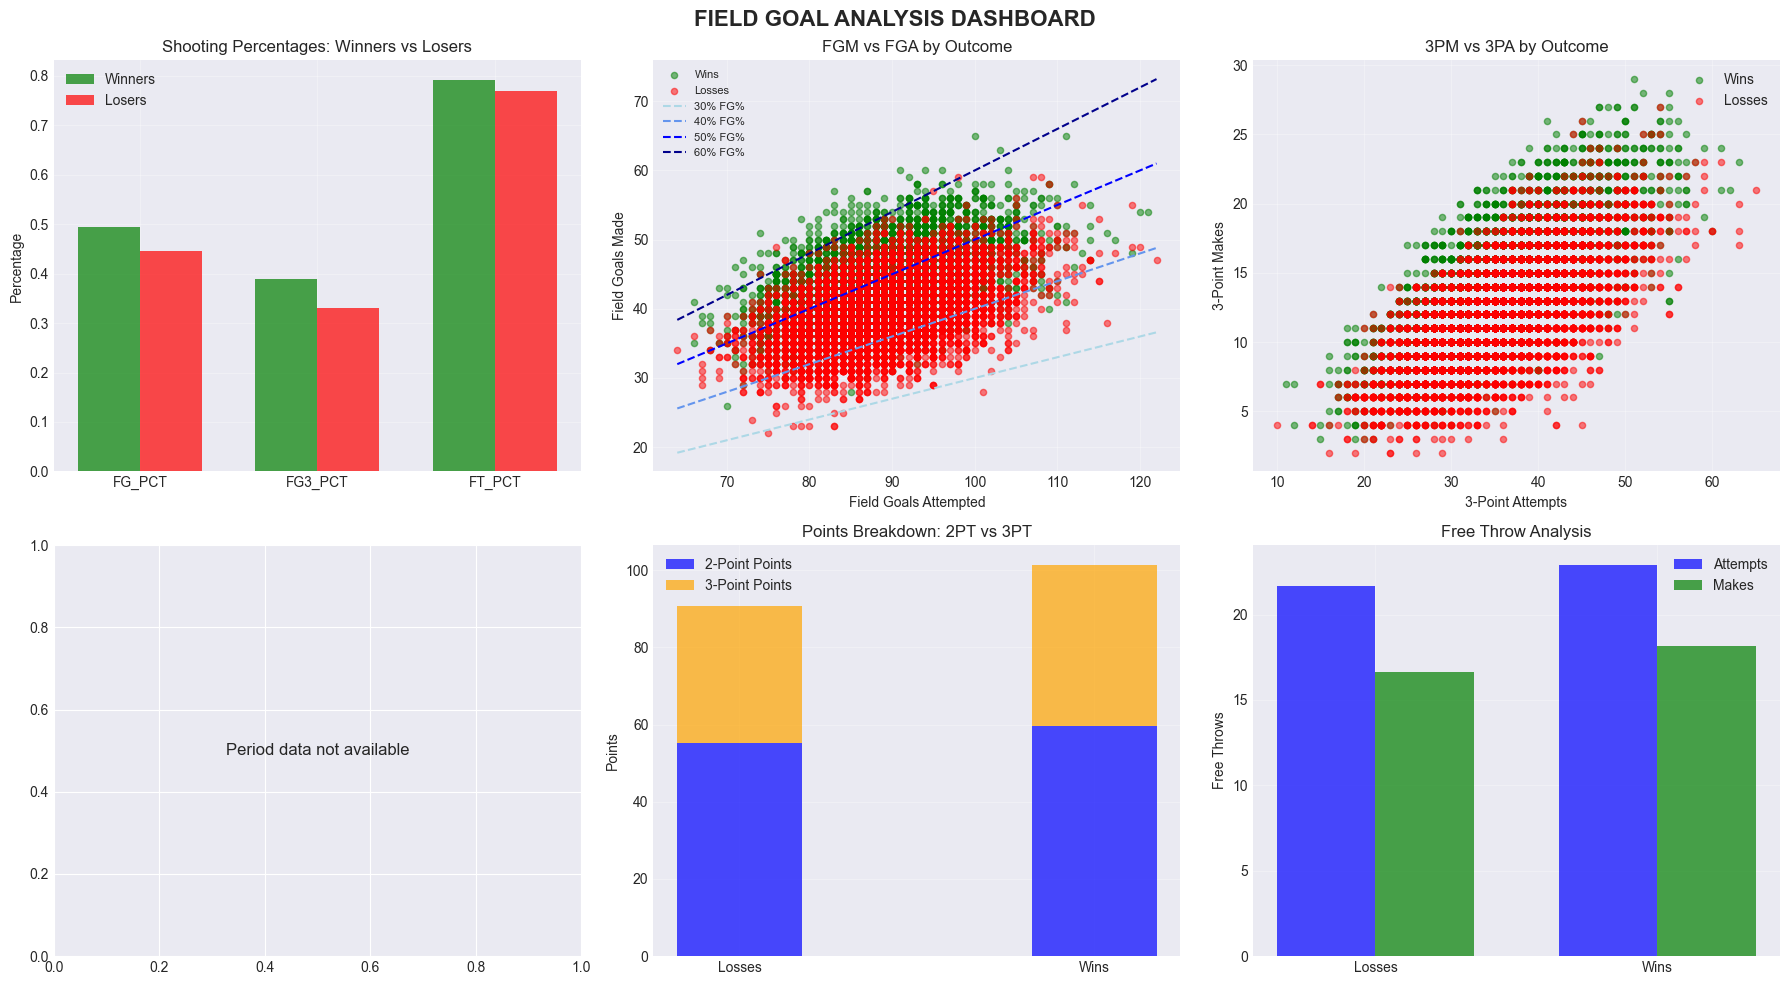

In [166]:
#  FIELD GOAL ANALYSIS

print("\n" + "="*80)
print("PART 2: FIELD GOAL ANALYSIS")
print("="*80)

# Shooting analysis visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Shooting percentages distribution
ax1 = axes[0, 0]
shooting_stats = ['fg_pct', 'fg3_pct', 'ft_pct']
shooting_data = []
for stat in shooting_stats:
    if stat in in_game_df.columns:
        shooting_data.append({
            'Stat': stat.upper(),
            'Winners': in_game_df[in_game_df['win']==1][stat].mean(),
            'Losers': in_game_df[in_game_df['win']==0][stat].mean()
        })

shooting_df = pd.DataFrame(shooting_data)
x = np.arange(len(shooting_df))
width = 0.35
ax1.bar(x - width/2, shooting_df['Winners'], width, label='Winners', color='green', alpha=0.7)
ax1.bar(x + width/2, shooting_df['Losers'], width, label='Losers', color='red', alpha=0.7)
ax1.set_xticks(x)
ax1.set_xticklabels(shooting_df['Stat'])
ax1.set_ylabel('Percentage')
ax1.set_title('Shooting Percentages: Winners vs Losers')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Field goals made vs attempted
ax2 = axes[0, 1]
if 'fgm' in in_game_df.columns and 'fga' in in_game_df.columns:
    ax2.scatter(in_game_df[in_game_df['win']==1]['fga'], 
               in_game_df[in_game_df['win']==1]['fgm'], 
               alpha=0.5, label='Wins', color='green', s=20)
    ax2.scatter(in_game_df[in_game_df['win']==0]['fga'], 
               in_game_df[in_game_df['win']==0]['fgm'], 
               alpha=0.5, label='Losses', color='red', s=20)
    
    # Add efficiency lines with different colors and labels
    efficiencies = [0.3, 0.4, 0.5, 0.6]
    colors = ['lightblue', 'cornflowerblue', 'blue', 'darkblue']
    
    for eff, color in zip(efficiencies, colors):
        x_line = np.linspace(in_game_df['fga'].min(), in_game_df['fga'].max(), 10)
        y_line = eff * x_line
        ax2.plot(x_line, y_line, linestyle='--', color=color, 
                label=f'{eff:.0%} FG%', linewidth=1.5)
    
    ax2.set_xlabel('Field Goals Attempted')
    ax2.set_ylabel('Field Goals Made')
    ax2.set_title('FGM vs FGA by Outcome')
    ax2.legend(loc='best', fontsize=8)  # Adjust legend to fit all lines
    ax2.grid(True, alpha=0.3)




# 3. 3-Point analysis
ax3 = axes[0, 2]
if 'fg3m' in in_game_df.columns and 'fg3a' in in_game_df.columns:
    ax3.scatter(in_game_df[in_game_df['win']==1]['fg3a'], 
               in_game_df[in_game_df['win']==1]['fg3m'], 
               alpha=0.5, label='Wins', color='green', s=20)
    ax3.scatter(in_game_df[in_game_df['win']==0]['fg3a'], 
               in_game_df[in_game_df['win']==0]['fg3m'], 
               alpha=0.5, label='Losses', color='red', s=20)
    ax3.set_xlabel('3-Point Attempts')
    ax3.set_ylabel('3-Point Makes')
    ax3.set_title('3PM vs 3PA by Outcome')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# 4. Shooting efficiency by quarter (if available)
ax4 = axes[1, 0]
fg_pct_cols = [col for col in in_game_df.columns if 'fg_pct_' in col]
if fg_pct_cols:
    fg_by_period = in_game_df[fg_pct_cols].mean()
    ax4.plot(range(len(fg_by_period)), fg_by_period.values, marker='o', linewidth=2, color='blue')
    ax4.set_xticks(range(len(fg_by_period)))
    ax4.set_xticklabels([col.replace('fg_pct_', '').upper() for col in fg_by_period.index])
    ax4.set_ylabel('Field Goal %')
    ax4.set_title('FG% by Period')
    ax4.grid(True, alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'Period data not available', ha='center', va='center', fontsize=12)

# 5. 2PT vs 3PT scoring 
ax5 = axes[1, 1]
if all(col in in_game_df.columns for col in ['fgm', 'fg3m', 'fga', 'fg3a']):
    # Calculate 2-point and 3-point points
    in_game_df['pts_2pt'] = (in_game_df['fgm'] - in_game_df['fg3m']) * 2
    in_game_df['pts_3pt'] = in_game_df['fg3m'] * 3
    
    # Group by win/loss
    pts_2pt_by_outcome = in_game_df.groupby('win')['pts_2pt'].mean()
    pts_3pt_by_outcome = in_game_df.groupby('win')['pts_3pt'].mean()
    
    # Create the stacked bar chart
    x_pos = [0, 1]
    ax5.bar(x_pos, pts_2pt_by_outcome.values, width=0.35, label='2-Point Points', color='blue', alpha=0.7)
    ax5.bar(x_pos, pts_3pt_by_outcome.values, width=0.35, bottom=pts_2pt_by_outcome.values, 
            label='3-Point Points', color='orange', alpha=0.7)
    
    ax5.set_xticks(x_pos)
    ax5.set_xticklabels(['Losses', 'Wins'])
    ax5.set_ylabel('Points')
    ax5.set_title('Points Breakdown: 2PT vs 3PT')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # Print the breakdown
    print("\n📊 Points Breakdown by Outcome:")
    print(f"Winners - 2PT: {pts_2pt_by_outcome[1]:.1f}, 3PT: {pts_3pt_by_outcome[1]:.1f}, Total: {pts_2pt_by_outcome[1] + pts_3pt_by_outcome[1]:.1f}")
    print(f"Losers  - 2PT: {pts_2pt_by_outcome[0]:.1f}, 3PT: {pts_3pt_by_outcome[0]:.1f}, Total: {pts_2pt_by_outcome[0] + pts_3pt_by_outcome[0]:.1f}")

# 6. Free throw analysis
ax6 = axes[1, 2]
if 'ftm' in in_game_df.columns and 'fta' in in_game_df.columns:
    ft_attempts_by_outcome = in_game_df.groupby('win')['fta'].mean()
    ft_makes_by_outcome = in_game_df.groupby('win')['ftm'].mean()
    
    x = np.arange(2)
    width = 0.35
    ax6.bar(x - width/2, ft_attempts_by_outcome.values, width, label='Attempts', color='blue', alpha=0.7)
    ax6.bar(x + width/2, ft_makes_by_outcome.values, width, label='Makes', color='green', alpha=0.7)
    ax6.set_xticks(x)
    ax6.set_xticklabels(['Losses', 'Wins'])
    ax6.set_ylabel('Free Throws')
    ax6.set_title('Free Throw Analysis')
    ax6.legend()
    ax6.grid(True, alpha=0.3)

plt.suptitle('FIELD GOAL ANALYSIS DASHBOARD', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Save the figure with transparency

In [167]:
# ----------------------------------------------------------------------
# Plot 1: Shooting percentages distribution (bar chart)
# ----------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(9, 5))
fig1.patch.set_alpha(0)
ax1.patch.set_alpha(0)

shooting_stats = ['fg_pct', 'fg3_pct', 'ft_pct']
shooting_data = []
for stat in shooting_stats:
    if stat in in_game_df.columns:
        shooting_data.append({
            'Stat': stat.upper(),
            'Winners': in_game_df[in_game_df['win']==1][stat].mean(),
            'Losers': in_game_df[in_game_df['win']==0][stat].mean()
        })

shooting_df = pd.DataFrame(shooting_data)
x = np.arange(len(shooting_df))
width = 0.35
ax1.bar(x - width/2, shooting_df['Winners'], width, label='Winners', color='green', alpha=0.7)
ax1.bar(x + width/2, shooting_df['Losers'], width, label='Losers', color='red', alpha=0.7)
ax1.set_xticks(x)
ax1.set_xticklabels(shooting_df['Stat'])
ax1.set_ylabel('Percentage')
ax1.set_title('Shooting Percentages: Winners vs Losers')
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(_plots_dir / 'shooting_percentages.png', transparent=True)
plt.close(fig1)

# ----------------------------------------------------------------------
# Plot 2: Field goals made vs attempted (with efficiency lines)
# ----------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(9, 5))
fig2.patch.set_alpha(0)
ax2.patch.set_alpha(0)

if 'fgm' in in_game_df.columns and 'fga' in in_game_df.columns:
    ax2.scatter(in_game_df[in_game_df['win']==1]['fga'], 
                in_game_df[in_game_df['win']==1]['fgm'], 
                alpha=0.5, label='Wins', color='green', s=20)
    ax2.scatter(in_game_df[in_game_df['win']==0]['fga'], 
                in_game_df[in_game_df['win']==0]['fgm'], 
                alpha=0.5, label='Losses', color='red', s=20)
    
    # Add efficiency lines
    efficiencies = [0.3, 0.4, 0.5, 0.6]
    colors = ['lightblue', 'cornflowerblue', 'blue', 'darkblue']
    
    for eff, color in zip(efficiencies, colors):
        x_line = np.linspace(in_game_df['fga'].min(), in_game_df['fga'].max(), 10)
        y_line = eff * x_line
        ax2.plot(x_line, y_line, linestyle='--', color=color, 
                 label=f'{eff:.0%} FG%', linewidth=1.5)
    
    ax2.set_xlabel('Field Goals Attempted')
    ax2.set_ylabel('Field Goals Made')
    ax2.set_title('FGM vs FGA by Outcome')
    ax2.legend(loc='best', fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(_plots_dir / 'fgm_vs_fga.png', transparent=True)
plt.close(fig2)

# ----------------------------------------------------------------------
# Plot 3: 3-Point analysis (3PM vs 3PA)
# ----------------------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(9, 5))
fig3.patch.set_alpha(0)
ax3.patch.set_alpha(0)

if 'fg3m' in in_game_df.columns and 'fg3a' in in_game_df.columns:
    ax3.scatter(in_game_df[in_game_df['win']==1]['fg3a'], 
                in_game_df[in_game_df['win']==1]['fg3m'], 
                alpha=0.5, label='Wins', color='green', s=20)
    ax3.scatter(in_game_df[in_game_df['win']==0]['fg3a'], 
                in_game_df[in_game_df['win']==0]['fg3m'], 
                alpha=0.5, label='Losses', color='red', s=20)
    ax3.set_xlabel('3-Point Attempts')
    ax3.set_ylabel('3-Point Makes')
    ax3.set_title('3PM vs 3PA by Outcome')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(_plots_dir / 'fg3m_vs_fg3a.png', transparent=True)
plt.close(fig3)

###  TIME-BASED ANALYSIS


PART 3: TIME-BASED ANALYSIS

📋 Available time-based columns:
  ✓ days_rest
  ✓ is_back_to_back

📊 Available plots: ['rest', 'b2b']


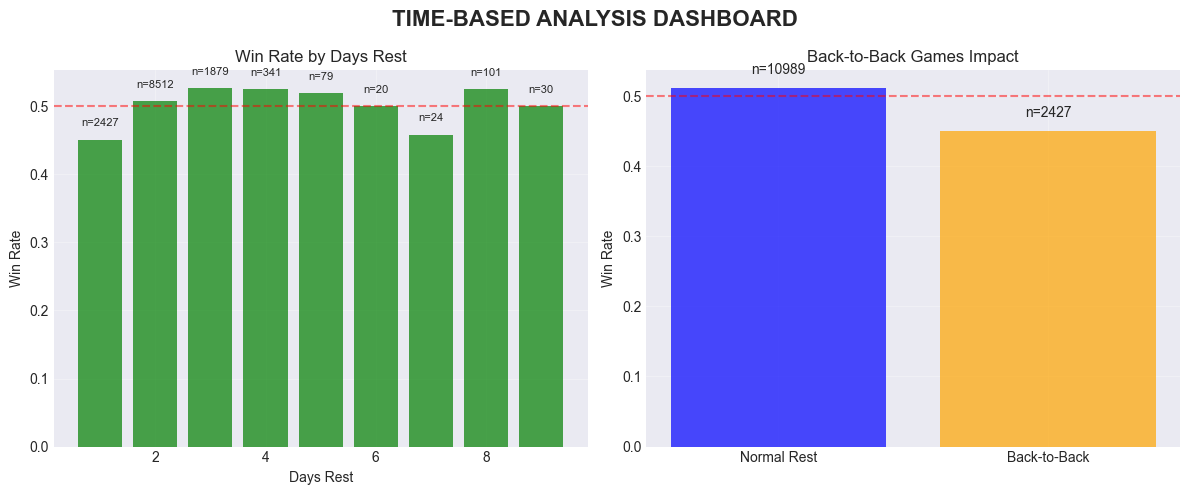

In [168]:
#  TIME-BASED ANALYSIS

print("\n" + "="*80)
print("PART 3: TIME-BASED ANALYSIS")
print("="*80)

# Check what time-based columns are actually available
print("\n📋 Available time-based columns:")
time_columns = ['game_date', 'minutes_played', 'days_rest', 'is_back_to_back', 'game_number']
available_time_cols = [col for col in time_columns if col in in_game_df.columns]
for col in available_time_cols:
    print(f"  ✓ {col}")

# Convert game_date if available
if 'game_date' in in_game_df.columns:
    in_game_df['game_date'] = pd.to_datetime(in_game_df['game_date'])
    in_game_df['year'] = in_game_df['game_date'].dt.year
    in_game_df['month'] = in_game_df['game_date'].dt.month
    in_game_df['day_of_week'] = in_game_df['game_date'].dt.dayofweek
    print("  ✓ Created month, day_of_week from game_date")

# Time-based visualizations - dynamically create subplots based on available data
available_plots = []

# Check each potential plot type
if 'month' in in_game_df.columns:
    available_plots.append('monthly')
if 'day_of_week' in in_game_df.columns:
    available_plots.append('dow')
if 'minutes_played' in in_game_df.columns:
    available_plots.append('minutes')
if 'days_rest' in in_game_df.columns:
    available_plots.append('rest')
if 'is_back_to_back' in in_game_df.columns:
    available_plots.append('b2b')
if 'game_number' in in_game_df.columns:
    available_plots.append('season')

print(f"\n📊 Available plots: {available_plots}")

# Calculate grid size
n_plots = len(available_plots)
if n_plots > 0:
    n_cols = min(3, n_plots)
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    fig.suptitle('TIME-BASED ANALYSIS DASHBOARD', fontsize=16, fontweight='bold')
    
    # Flatten axes for easy indexing
    if n_rows > 1:
        axes = axes.flatten()
    elif n_plots == 1:
        axes = [axes]
    
    plot_idx = 0
    
    
    
    # 1. Days rest impact
    if 'days_rest' in in_game_df.columns and 'rest' in available_plots:
        ax = axes[plot_idx]
        rest_impact = in_game_df.groupby('days_rest')['win'].agg(['mean', 'count'])
        rest_impact = rest_impact[rest_impact['count'] > 5]  # Filter low sample sizes
        
        ax.bar(rest_impact.index, rest_impact['mean'], color='green', alpha=0.7)
        ax.set_xlabel('Days Rest')
        ax.set_ylabel('Win Rate')
        ax.set_title('Win Rate by Days Rest')
        ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        
        # Add count labels
        for idx, value in rest_impact.iterrows():
            ax.text(idx, value['mean'] + 0.02, f'n={int(value["count"])}', ha='center', fontsize=8)
        plot_idx += 1
    
    # 2. Back-to-back games impact
    if 'is_back_to_back' in in_game_df.columns and 'b2b' in available_plots:
        ax = axes[plot_idx]
        b2b_stats = in_game_df.groupby('is_back_to_back')['win'].mean()
        b2b_counts = in_game_df.groupby('is_back_to_back')['win'].count()
        
        labels = ['Normal Rest', 'Back-to-Back'] if len(b2b_stats) > 1 else ['All Games']
        values = b2b_stats.values
        
        ax.bar(labels[:len(values)], values, color=['blue', 'orange'][:len(values)], alpha=0.7)
        ax.set_ylabel('Win Rate')
        ax.set_title('Back-to-Back Games Impact')
        ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        
        # Add count labels
        for i, (idx, count) in enumerate(b2b_counts.items()):
            if i < len(labels):
                ax.text(i, b2b_stats.iloc[i] + 0.02, f'n={count}', ha='center')
        plot_idx += 1
    
    # Hide any unused subplots
    for idx in range(plot_idx, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

else:
    print("\n❌ No time-based columns available for visualization")


### Save the figure with transparency

In [169]:
# ----------------------------------------------------------------------
# Plot 1: Win Rate by Days Rest
# ----------------------------------------------------------------------
if 'days_rest' in in_game_df.columns:
    fig1, ax1 = plt.subplots(figsize=(8, 5))
    fig1.patch.set_alpha(0)       # transparent figure background
    ax1.patch.set_alpha(0)        # transparent axes background

    # Prepare data
    rest_impact = in_game_df.groupby('days_rest')['win'].agg(['mean', 'count'])
    rest_impact = rest_impact[rest_impact['count'] > 5]   # filter low sample sizes

    # Bar chart
    ax1.bar(rest_impact.index, rest_impact['mean'], color='green', alpha=0.7)
    ax1.set_xlabel('Days Rest')
    ax1.set_ylabel('Win Rate')
    ax1.set_title('Win Rate by Days Rest')
    ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
    ax1.grid(True, alpha=0.3)

    # Add sample size labels
    for idx, value in rest_impact.iterrows():
        ax1.text(idx, value['mean'] + 0.02, f'n={int(value["count"])}', 
                 ha='center', fontsize=8)

    plt.tight_layout()
    plt.savefig(_plots_dir / 'winrate_by_daysrest.png', transparent=True)
    plt.close(fig1)
    print("✓ Saved: winrate_by_daysrest.png")
else:
    print("❌ 'days_rest' column not found – skipping plot 1")

# ----------------------------------------------------------------------
# Plot 2: Back-to-Back Games Impact
# ----------------------------------------------------------------------
if 'is_back_to_back' in in_game_df.columns:
    fig2, ax2 = plt.subplots(figsize=(6, 5))
    fig2.patch.set_alpha(0)
    ax2.patch.set_alpha(0)

    # Prepare data
    b2b_stats = in_game_df.groupby('is_back_to_back')['win'].mean()
    b2b_counts = in_game_df.groupby('is_back_to_back')['win'].count()
    labels = ['Normal Rest', 'Back-to-Back'] if len(b2b_stats) > 1 else ['All Games']
    values = b2b_stats.values

    # Bar chart
    ax2.bar(labels[:len(values)], values, color=['blue', 'orange'][:len(values)], alpha=0.7)
    ax2.set_ylabel('Win Rate')
    ax2.set_title('Back-to-Back Games Impact')
    ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
    ax2.grid(True, alpha=0.3)

    # Add sample size labels
    for i, (idx, count) in enumerate(b2b_counts.items()):
        if i < len(labels):
            ax2.text(i, b2b_stats.iloc[i] + 0.02, f'n={count}', ha='center')

    plt.tight_layout()
    plt.savefig(_plots_dir / 'backtoback_impact.png', transparent=True)
    plt.close(fig2)
    print("✓ Saved: backtoback_impact.png")
else:
    print("❌ 'is_back_to_back' column not found – skipping plot 2")

✓ Saved: winrate_by_daysrest.png
✓ Saved: backtoback_impact.png


<h1 style="text-align:center; text-decoration:underline; margin-bottom:10px;">
Model Development
</h1>

In [170]:
plt.style.use('default')   # reset matplotlib style
sns.reset_orig()    

## Import Data

We will be using already cleaned data that was created by running scripts/preprocessing.py. The cleaned data CSV is located at cleaned_data/cleaned_data_2_21_26.csv. Some columns in the cleaned data will not be used in the EDA and modelings and must be removed before proceeding.

In [171]:
box_score_df = pd.read_csv(_cleaned_data_dir / "cleaned_data_2_21_26.csv")

unneeded_identifying_cols = ['team_name','opponent_name', 'opponent_pts', 'team_box_id', 
                                'game_id', 'team_id', 'season_year', 'game_date',  'neutral_site', 
                                'opponent_team_id', 'game_number']

unneeded_in_game_stats_cols = ['win', 'pts', 'fgm', 'fga', 'fg_pct', 'fg3m', 'fg3a', 'fg3_pct', 
                                'ftm', 'fta', 'ft_pct', 'oreb', 'dreb', 'reb', 'ast', 'tov', 
                                'stl', 'blk', 'blka', 'pf', 'pfd', 'pace', 'poss', 'minutes_played']

unneeded_team_summary_cols = ['total_wins', 'total_losses', 'diff_pts', 'diff_ast', 'diff_tov',
                                'total_wins', 'total_losses', 'diff_pts', 'diff_ast', 'diff_tov',
                                'diff_blk', 'diff_blka', 'diff_fgm', 'diff_fga', 'diff_ftm',
                                'diff_fta', 'diff_pf', 'diff_pfd', 'diff_stl', 'diff_oreb', 'diff_dreb',
                                'diff_fg3m', 'diff_fg3a', "diff_reb", "wins_last_10_average", "wins_last_5_average",
                                "win_percentage_average", "win_percentage_last_10_average", 
                                "wins_last_10_rolling_mean_prev_10", "win_percentage_rolling_mean_prev_10",
                                "win_percentage_last_10_rolling_mean_prev_10", "diff_wins_last_10", "wins_last_10"] 

unneeded_diff_cols = ['diff_days_rest_average', 'diff_days_rest_rolling_mean_prev_5', 'diff_win_percentage_average',
                        'diff_win_percentage_last_10_average', 'diff_win_percentage_last_10_rolling_mean_prev_5',
                        'diff_win_percentage_last_5_average', 'diff_win_percentage_last_5_rolling_mean_prev_5',
                        'diff_win_percentage_rolling_mean_prev_5', 'diff_wins_last_10_average',
                        'diff_wins_last_10_rolling_mean_prev_5', 'diff_wins_last_5_average',
                        'diff_wins_last_5_rolling_mean_prev_5', "diff_win_percentage_rolling_mean_prev_10"]

col_prefixes = ['diff_days_rest_rolling_mean_prev_', 'diff_win_percentage_last_10_rolling_mean_prev_', 'diff_win_percentage_last_5_rolling_mean_prev_'
'diff_win_percentage_rolling_mean_prev_', 'diff_wins_last_10_rolling_mean_prev_', 'diff_wins_last_5_rolling_mean_prev_']

cols_to_ignore = []
for prefix in col_prefixes:
    cols_to_ignore.extend([col for col in box_score_df.columns if col.startswith(prefix)])

unneeded_cols = unneeded_identifying_cols + unneeded_in_game_stats_cols + unneeded_team_summary_cols + unneeded_diff_cols + cols_to_ignore

x_cols = [col for col in box_score_df.columns if col not in unneeded_cols]
y_col = ["win"]

##### Create Datasets: X, Y, and train/test split

In [172]:
X = box_score_df[x_cols]
y = box_score_df[y_col].squeeze().astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

<h2 style="text-align: center;"> Logistic Regression Modeling<h2>
<br>

In [173]:
# Logistic regression settings
LOAD_MODELS = True
SAVE_MODELS = False


### LR1:
Logistic regression modeling using the top 15 features identified from the XGBoost permutation importance 

In [174]:
# These are the top 15 most important features identified by feature permutation importance from the XGBOOST models
X_log_reg_numeric_cols = [
    'pace_average',
    'blka_average',
    'pfd_average',
    'diff_fg3a_average',
    'dreb_average',
    'diff_ftm_average',
    'diff_fgm_average',
    'diff_pace_average',
    'diff_days_rest',
    'is_home',
    'diff_pts_average',
    'win_percentage_last_10',
    'diff_win_percentage_last_10',
    'win_percentage',
    'diff_win_percentage'
]

# Manually filtered features
X_mf = box_score_df[X_log_reg_numeric_cols]
y_mf = box_score_df[y_col].squeeze().astype(int)
logistic_param_grid={"lr__C": range(1, 100)}
X_train_mf = X_train[X_log_reg_numeric_cols]
X_test_mf = X_test[X_log_reg_numeric_cols]
y_train_mf = y_train
y_test_mf = y_test

log_reg_clf = LogisticRegressor()

print("Logistic regression accuracy and best param")
print("="*60)
log_reg_clf.run(X_train_mf, y_train_mf, X_test_mf, y_test_mf, param_grid=logistic_param_grid)

# DataFrame of coefficients and feature names, sorted by coefficient value
print("\n\n")
print("Logisitic Regression Coefficients")
print("="*60)
coef_df = pd.DataFrame({
    "feature": X_train_mf.columns.tolist(),
    "coef": log_reg_clf.clf.best_estimator_.named_steps["lr"].coef_[0],
    'abs_coef': np.abs(log_reg_clf.clf.best_estimator_.named_steps["lr"].coef_[0])
}).sort_values("abs_coef", ascending=False)
display(coef_df)

print("\n\n")
print("Logistic Regression Equation")
print("="*60)
log_reg_clf.print_logistic_regression_equation(X_train_mf)


Logistic regression accuracy and best param
CV accuracy (train CV): 0.7214365667414407
Best params: {'lr__C': 42}
Test accuracy: 0.7170186335403727



Logisitic Regression Coefficients


,feature,coef,abs_coef
14,diff_win_percentage,1.904770,1.904770
12,diff_win_percentage_last_10,-0.793840,0.793840
9,is_home,0.241026,0.241026
8,diff_days_rest,0.140775,0.140775
6,diff_fgm_average,0.064737,0.064737
3,diff_fg3a_average,-0.049043,0.049043
10,diff_pts_average,0.044061,0.044061
13,win_percentage,-0.042653,0.042653
11,win_percentage_last_10,-0.031786,0.031786
5,diff_ftm_average,-0.030916,0.030916





Logistic Regression Equation
z = -0.0001  -0.0104*pace_average + 0.0089*blka_average  -0.0004*pfd_average  -0.0490*diff_fg3a_average + 0.0251*dreb_average  -0.0309*diff_ftm_average + 0.0647*diff_fgm_average  -0.0033*diff_pace_average + 0.1408*diff_days_rest + 0.2410*is_home + 0.0441*diff_pts_average  -0.0318*win_percentage_last_10  -0.7938*diff_win_percentage_last_10  -0.0427*win_percentage + 1.9048*diff_win_percentage
P(win) = 1 / (1 + exp(-z))


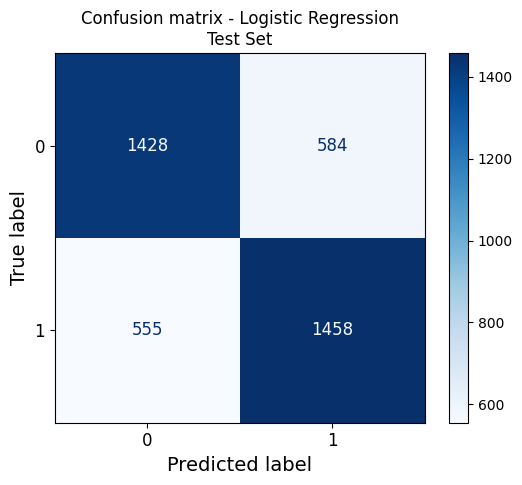

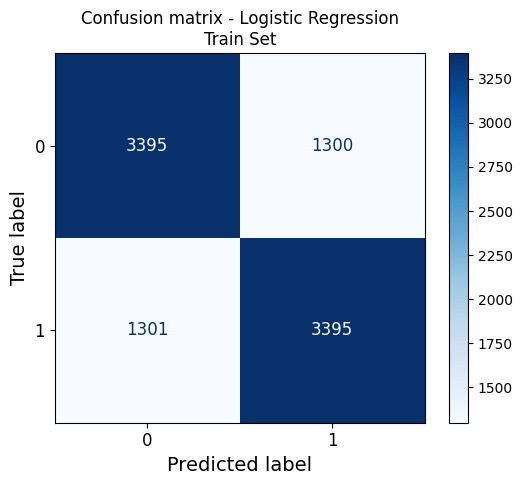

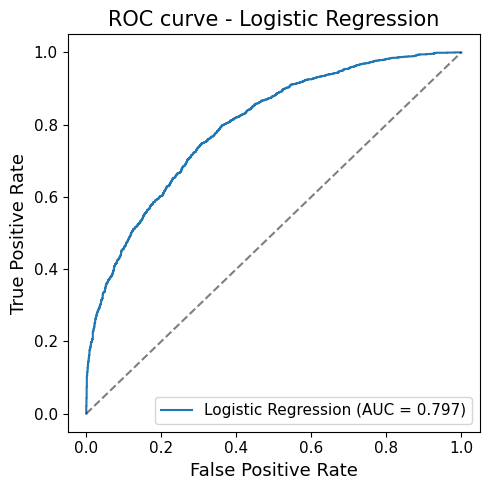

<Axes: title={'center': 'ROC curve - Logistic Regression'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [175]:
# LR1 confusion matrices and ROC curve
log_reg_clf.plt_confusion_matrix(X_test_mf, y_test_mf, is_test=True, save_path=_plots_dir / "log_reg_test_confusion_matrix.png")
log_reg_clf.plt_confusion_matrix(X_train_mf, y_train_mf, is_test=False, save_path=_plots_dir / "log_reg_train_confusion_matrix.png")
log_reg_clf.plot_roc_curve(X_test_mf, y_test_mf, save_path=_plots_dir / "log_reg_test_roc_curve.png")



### LR2:
Logistic regression using principal components from PCA 

In [176]:
if LOAD_MODELS:
    pca = joblib.load(_models_dir / "pca_logistic_regressor_60_component.joblib")
else:
    param_grid = {
        "pca__n_components": range(1, 60 + 1),
        "logistic__C": np.logspace(-3, 3, 15),
    }
    pca = PCALogisticRegressor(max_components=60)
    pca.run(X_train, y_train, X_test, y_test, param_grid=param_grid, refit=True)
    if SAVE_MODELS:
        _models_dir.mkdir(parents=True, exist_ok=True)
        joblib.dump(pca, _models_dir / "pca_logistic_regressor_60_component.joblib")

pca.print_logistic_regression_equation(X_train, y_train)


z = 0.0003 + 0.2277*PC1 + 0.0337*PC2  -0.0175*PC3  -0.0941*PC4  -0.0768*PC5 + 0.0047*PC6 + 0.0315*PC7  -0.0812*PC8 + 0.0558*PC9 + 0.1409*PC10 + 0.0522*PC11 + 0.0840*PC12 + 0.0320*PC13 + 0.4625*PC14 + 0.3381*PC15 + 0.3297*PC16 + 0.1676*PC17 + 0.2462*PC18 + 0.3201*PC19 + 0.0977*PC20  -0.0471*PC21  -0.1150*PC22 + 0.1613*PC23 + 0.2224*PC24  -0.1951*PC25  -0.1476*PC26 + 0.1585*PC27  -0.1335*PC28 + 0.0584*PC29  -0.1152*PC30 + 0.3171*PC31  -0.0598*PC32 + 0.1079*PC33 + 0.3452*PC34  -0.3189*PC35  -0.4170*PC36  -0.0826*PC37 + 0.0558*PC38 + 0.1881*PC39  -1.5319*PC40 + 0.0165*PC41 + 0.3487*PC42 + 0.4195*PC43 + 0.1222*PC44 + 0.2830*PC45  -0.2644*PC46 + 0.4531*PC47 + 0.2385*PC48 + 0.0915*PC49  -0.1239*PC50 + 0.0433*PC51  -0.2109*PC52 + 0.0367*PC53 + 0.2049*PC54  -0.2458*PC55  -0.2523*PC56 + 0.0614*PC57 + 0.2569*PC58  -0.0433*PC59
P(win) = 1 / (1 + exp(-z))



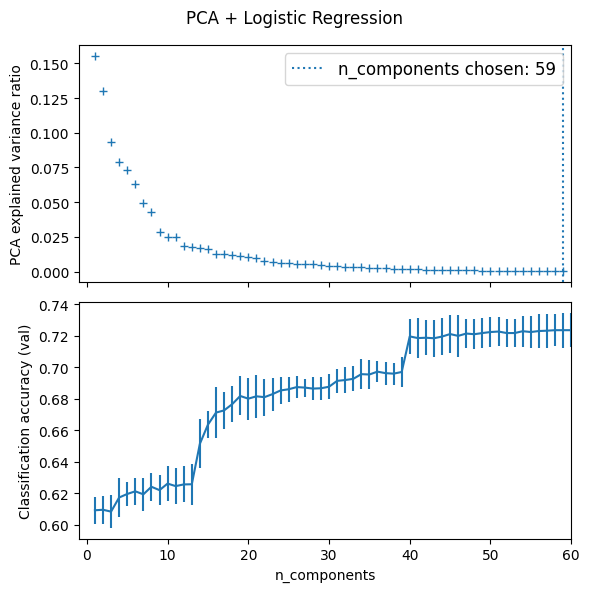

In [177]:
# Plot Varaince explained vs num PC and model accuracy vs num PC
pca.plot_cv_vs_components(save_path=_plots_dir / "pca_cv_vs_components.png")

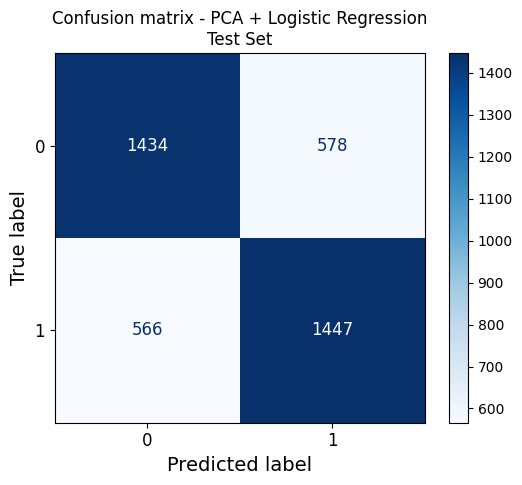

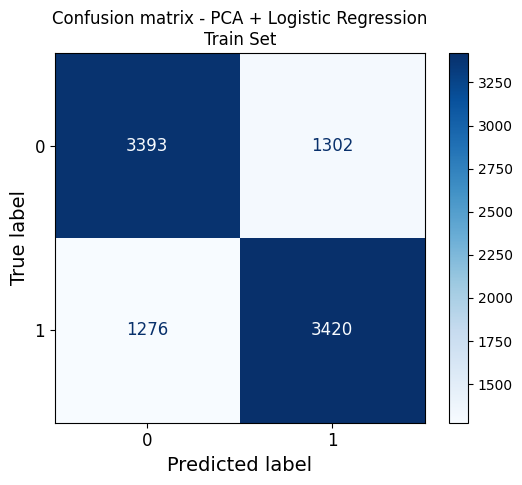

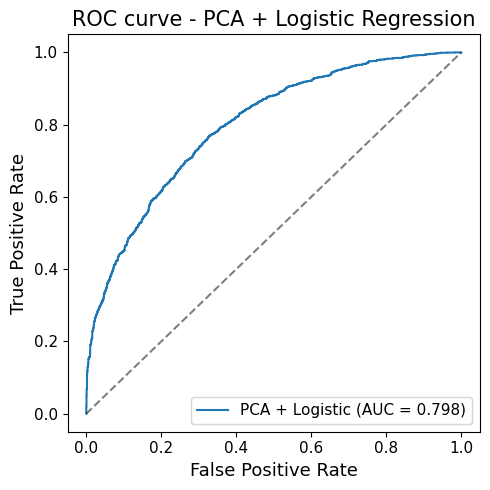

<Axes: title={'center': 'ROC curve - PCA + Logistic Regression'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [178]:
# Confusion Matrices and roc curve
pca.plt_confusion_matrix(X_test, y_test, is_test=True, save_path=_plots_dir / "pca_test_confusion_matrix.png")
pca.plt_confusion_matrix(X_train, y_train, is_test=False, save_path=_plots_dir / "pca_train_confusion_matrix.png")
pca.plot_roc_curve(X_test, y_test, save_path=_plots_dir / "pca_test_roc_curve.png")

### LR3:
Logistic regression using scores components from PLS 

In [179]:
if LOAD_MODELS:
    # _project_root = Path(__file__).resolve().parent.parent
    pls = joblib.load(_models_dir / "pls_logistic_regressor_60_component.joblib")
else:

    param_grid = {
        "pls__n_components": range(1, 60 + 1),
        "logistic__C": np.logspace(-3, 3, 15),
    }

    pls = PLSLogisticRegressor(max_components=60)
    pls.run(X_train, y_train, X_test, y_test, param_grid=param_grid, refit=True)
    if SAVE_MODELS:
        _models_dir.mkdir(parents=True, exist_ok=True)
        joblib.dump(pls, _models_dir / "pls_logistic_regressor_60_component.joblib")

pls.print_logistic_regression_equation(X_train, y_train)

z = 0.0010 + 0.2968*PC1 + 0.4932*PC2 + 0.2834*PC3 + 0.1203*PC4 + 0.2187*PC5 + 0.2454*PC6  -0.1392*PC7  -0.1731*PC8  -0.0814*PC9  -0.1076*PC10 + 0.0657*PC11 + 0.0924*PC12 + 0.0351*PC13 + 0.0689*PC14 + 0.0753*PC15  -0.0431*PC16  -0.0817*PC17
P(win) = 1 / (1 + exp(-z))



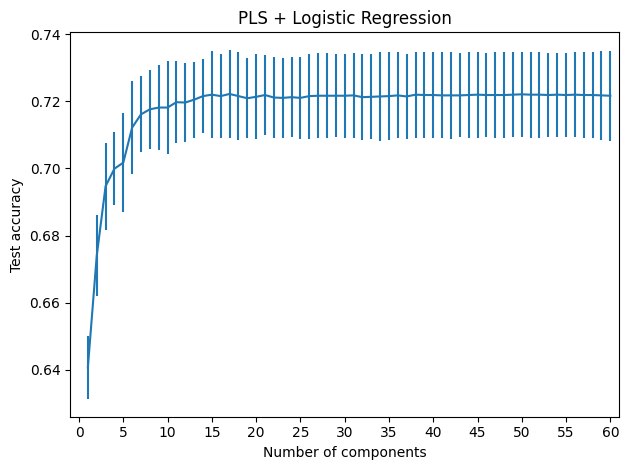

In [180]:
# Plot model accuracy vs num scores included
pls.plot_cv_vs_components(save_path=_plots_dir / "pls_cv_vs_components.png")

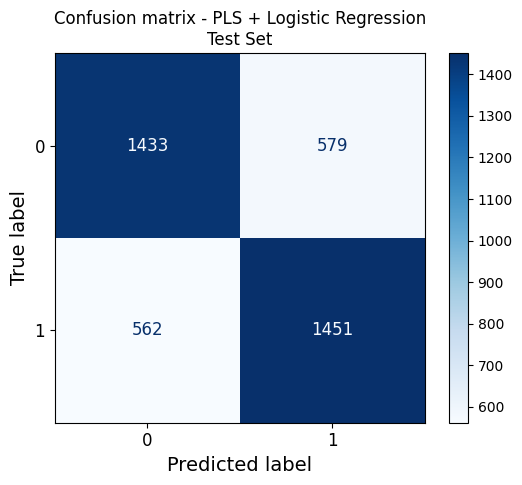

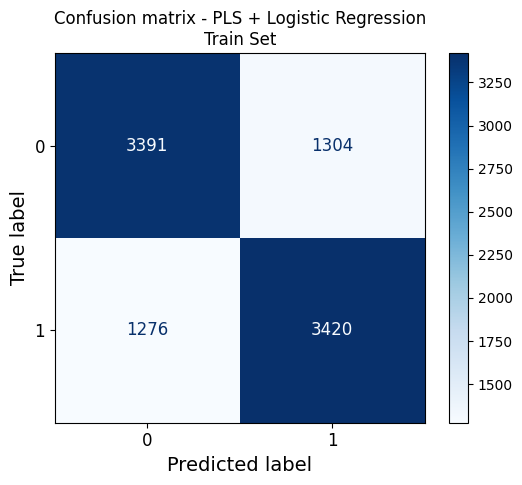

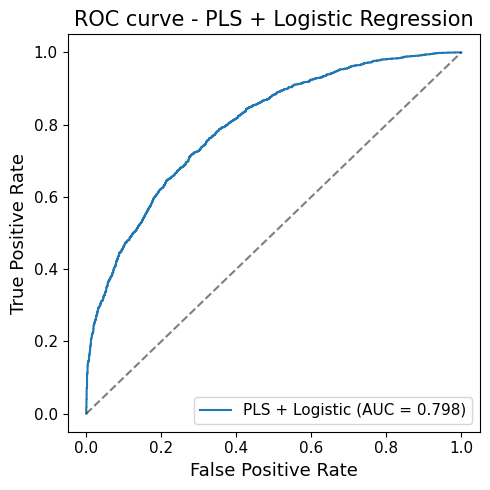

<Axes: title={'center': 'ROC curve - PLS + Logistic Regression'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [181]:
# Plot confusion matrices and roc curve 
pls.plt_confusion_matrix(X_test, y_test, is_test=True, save_path=_plots_dir / "pls_test_confusion_matrix.png")
pls.plt_confusion_matrix(X_train, y_train, is_test=False, save_path=_plots_dir / "pls_train_confusion_matrix.png")
  
pls.plot_roc_curve(X_test, y_test, save_path=_plots_dir / "pls_test_roc_curve.png")

### Logistic regression model comparison:
Plotting ROC curves for LR1, LR2, and LR3 

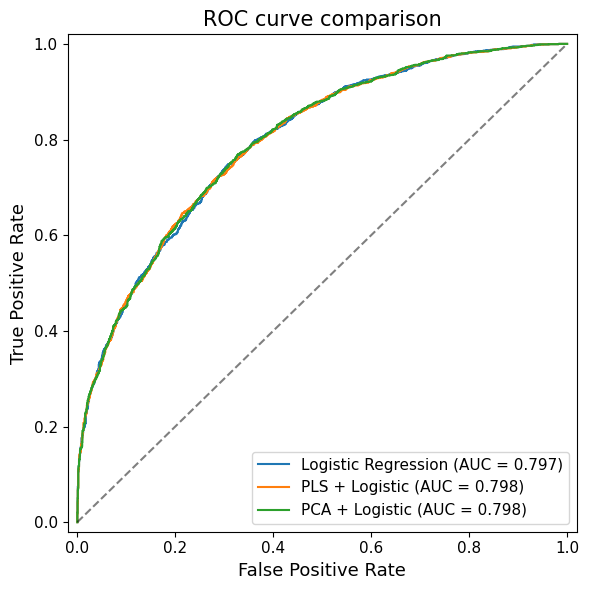

<Axes: title={'center': 'ROC curve comparison'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [182]:
plot_roc_compare(log_reg=log_reg_clf, pls=pls, pca=pca, X_log_reg=X_test_mf, X_pls=X_test, X_pca=X_test, y=y_test, save_path=_plots_dir / "roc_compare.png")


<h2 style="text-align: center;"> Gradient Boosted Classification Tree Models<h2>
<br>

A 5-fold cross-validation gird search was performed to identify the best hyperparameters. The hyperparameter grid searched was

| Parameter       | Values                          |
|----------------|----------------------------------|
| `max_depth`    | 5, 6, 7                          |
| `n_estimators` | 100, 150, 175, 200, 250          |
| `gamma`        | 0.075, 0.1, 0.2                  |
| `learning_rate`| 0.05, 0.1, 0.125, 0.15, 0.2      |
| `alpha`        | 0.0, 0.1, 0.2 (L1 regularization)|


The complete grid search results are loaded from `models/xgb_full_grid_clf_2026-03-03_16-11-54.joblib`.

The best params will be used to train the full feature and model using the top 15 features identified by permutation feature importance

In [183]:
# ================================================================
# Train the full model
# ================================================================fx
xgb_model = xgb.XGBClassifier(
    # n_jobs=multiprocessing.cpu_count() // 2, tree_method="hist"
    n_jobs=1, tree_method="hist"
)

clf = joblib.load(_models_dir / "xgb_full_grid_clf_2026-03-03_16-11-54.joblib")
best_params = clf.best_params_
model = train_xgboost(xgb_model, X_train, y_train, params=best_params, cv=5, save_model=False)

# ================================================================
# Evaluate the model
# ================================================================
y_pred_xgb = model.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Test Accuracy: {accuracy_xgb * 100:.2f}%")



0.9617719092748376
{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': 0.1, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 7, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 250, 'n_jobs': 1, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': None, 'alpha': 0.2}
Test Accuracy: 73.47%


Plotting distribution of accuracy from grid search

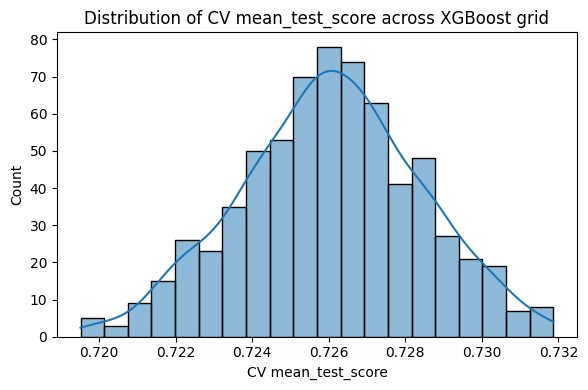

In [184]:
# ================================================================
# Plot distbrution of CV accuracy
# ================================================================
cv_res = clf.cv_results_
results_df = pd.DataFrame({
    "max_depth": np.asarray(cv_res["param_max_depth"], dtype=int),
    "n_estimators": np.asarray(cv_res["param_n_estimators"], dtype=int),
    "mean_test_score": cv_res["mean_test_score"],
    "std_test_score": cv_res["std_test_score"],
})
plt.figure(figsize=(6, 4))
sns.histplot(data=results_df, x="mean_test_score", bins=20, kde=True)
plt.xlabel("CV mean_test_score")
plt.ylabel("Count")
plt.title("Distribution of CV mean_test_score across XGBoost grid")
plt.tight_layout()
plt.savefig(_plots_dir / "xgb_cv_accuracy_distribution.png", transparent=True, dpi=300)
plt.show()

## Feature Importance

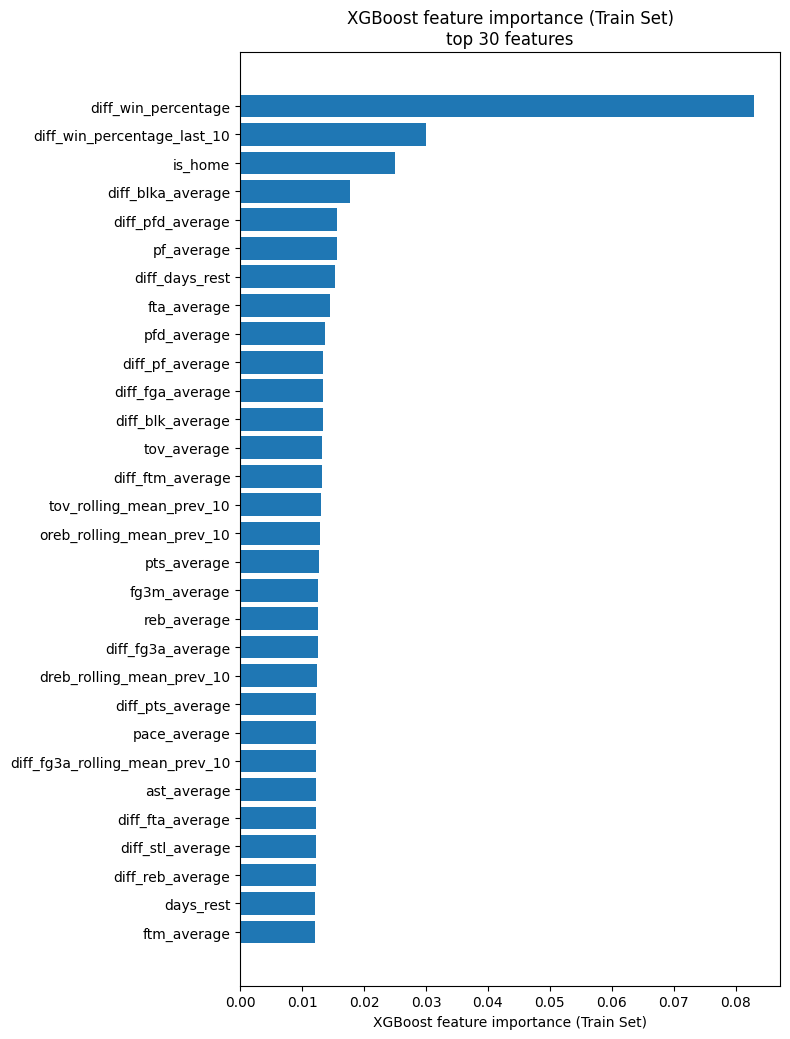

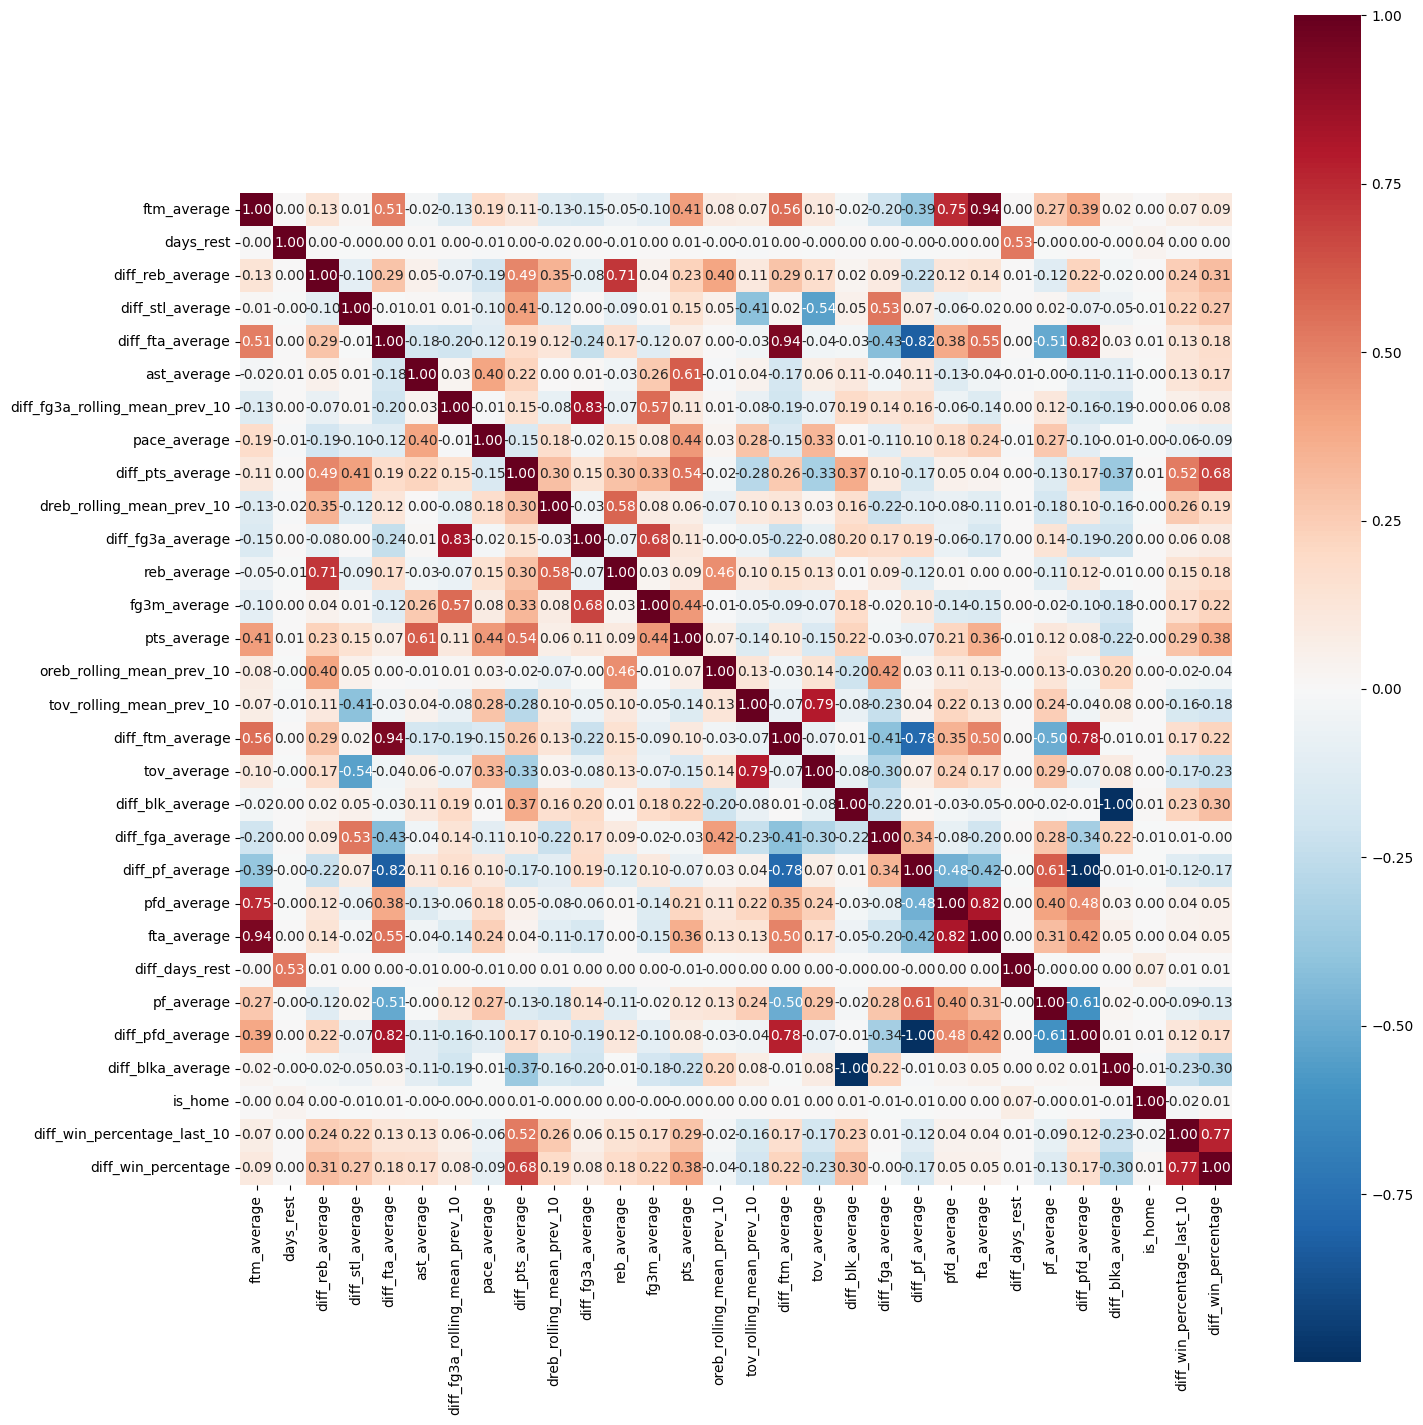

In [185]:
# ================================================================
# Feature importance and feature correlation on test set
# ================================================================
IMPORTANCE_THRESHOLD = 1e-5
top_n_features = 30

best = model
feature_names = X_train.columns
importances = best.feature_importances_
importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_filtered = importance_df[importance_df["importance"] >= IMPORTANCE_THRESHOLD].sort_values(
    by="importance", ascending=True
).tail(top_n_features)
plt.figure(figsize=(8, max(6, len(importance_filtered) * 0.35)))
plt.barh(importance_filtered["feature"], importance_filtered["importance"])
plt.xlabel("XGBoost feature importance (Train Set)")
plt.title(f"XGBoost feature importance (Train Set)\ntop {top_n_features} features")
plt.tight_layout()
plt.savefig(_plots_dir / "xgb_full_feature_model_feature_importance_train.png", transparent=True, dpi=300)
plt.show()

important_features = importance_filtered["feature"].tolist()
corr_important_features = X[important_features].corr()

n_features = len(important_features)
plt.figure(figsize=(max(8, n_features * 0.5), max(6, n_features * 0.5)))
sns.heatmap(corr_important_features, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.tight_layout()
plt.show()

# Permutation Feature Importance

Plotting permutation feature importance and training a new model using the top 15 features identified by permutation importance

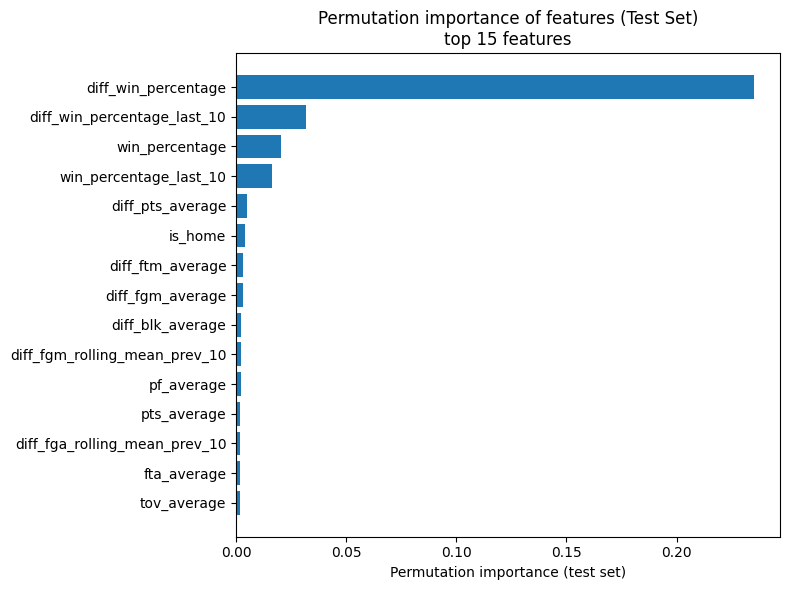

In [186]:
# ================================================================
# Permutation importance on test set
# ================================================================
best = model
feature_names = X_train.columns
PERMUTATION_IMPORTANCE_THRESHOLD = 1e-3
top_n_features = 15
perm = permutation_importance(best, X_test, y_test, n_repeats=20, random_state=42, n_jobs=1)
sorted_idx_perm = perm.importances_mean.argsort()
perm_importance_df = pd.DataFrame({
    "feature": feature_names[sorted_idx_perm],
    "permutation_importance_mean": perm.importances_mean[sorted_idx_perm],
})
perm_importance_filtered = perm_importance_df[
    perm_importance_df["permutation_importance_mean"].abs() >= 
    PERMUTATION_IMPORTANCE_THRESHOLD
].sort_values(by="permutation_importance_mean", ascending=True).tail(top_n_features)

plt.figure(figsize=(8, max(6, len(perm_importance_filtered) * 0.35)))
plt.barh(perm_importance_filtered["feature"], perm_importance_filtered["permutation_importance_mean"])
plt.xlabel("Permutation importance (test set)")
plt.title(f"Permutation importance of features (Test Set)\ntop {top_n_features} features")
plt.tight_layout()
plt.savefig(_plots_dir / "xgb_full_feature_model_permutation_importance_test.png", transparent=True, dpi=300)
plt.show()


In [187]:
# ================================================================
# Rerun with 15 most important features from permutation importance
# ================================================================
xgb_model_top = xgb.XGBClassifier(
    # n_jobs=multiprocessing.cpu_count() // 2, tree_method="hist"
    n_jobs=1, tree_method="hist"

)

n_features = 15
top_features = perm_importance_filtered.iloc[-n_features:]["feature"].values.tolist()
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]
model_top = train_xgboost(xgb_model_top, X_train_top, y_train, params=best_params, cv=5, save_model=False)
y_pred_top_xgb = model_top.predict(X_test_top)
accuracy_top_xgb = accuracy_score(y_test, y_pred_top_xgb)
print(f"Accuracy: {accuracy_top_xgb * 100:.2f}%")

0.9007560430199126
{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': 0.1, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 7, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 250, 'n_jobs': 1, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': None, 'alpha': 0.2}
Accuracy: 73.42%


<h2 style="text-align: center;"> Model Comparison<h2>
<br>

In [188]:
def calc_jaccard_score(*sets_):
    inter = set.intersection(*sets_)
    union = set.union(*sets_)
    return len(inter) / len(union)

# Get indices of misclassification for each model
xgb_top_mis_idx = set(np.where(y_test != y_pred_top_xgb)[0])
xgb_mis_idx = set(np.where(y_test != y_pred_xgb)[0])
log_reg_misclassification_indices = set(np.where(y_test != log_reg_clf.predict(X_test_mf))[0])
pls_misclassification_indices = set(np.where(y_test != pls.predict(X_test))[0])
pca_misclassification_indices = set(np.where(y_test != pca.predict(X_test))[0])

# Calculate Jaccard score for each model
log_reg_and_PCA = calc_jaccard_score(log_reg_misclassification_indices, pca_misclassification_indices)
log_reg_and_PLS = calc_jaccard_score(log_reg_misclassification_indices, pls_misclassification_indices)
pca_and_PLS = calc_jaccard_score(pca_misclassification_indices, pls_misclassification_indices)
log_reg_and_PCA_and_PLS = calc_jaccard_score(log_reg_misclassification_indices, pca_misclassification_indices, pls_misclassification_indices)
log_reg_and_XGB_top = calc_jaccard_score(log_reg_misclassification_indices, xgb_top_mis_idx)
log_reg_PLS_and_XGB_top = calc_jaccard_score(log_reg_misclassification_indices, pls_misclassification_indices, xgb_top_mis_idx)
log_reg_PCA_and_XGB_top = calc_jaccard_score(log_reg_misclassification_indices, pca_misclassification_indices, xgb_top_mis_idx)
xgb_and_xgb_top = calc_jaccard_score(xgb_mis_idx, xgb_top_mis_idx)
log_reg_PLS_and_XGB = calc_jaccard_score(log_reg_misclassification_indices, xgb_mis_idx, pls_misclassification_indices)
log_reg_PCA_and_XGB = calc_jaccard_score(log_reg_misclassification_indices, xgb_mis_idx, pca_misclassification_indices)
log_reg_and_XGB = calc_jaccard_score(log_reg_misclassification_indices, xgb_mis_idx)

jaccard_results = pd.DataFrame({
    "Jaccard score": {
        "Logistic Reg & PCA": log_reg_and_PCA,
        "Logistic Reg & PLS": log_reg_and_PLS,
        "PCA & PLS": pca_and_PLS,
        "Logistic Reg & PCA & PLS": log_reg_and_PCA_and_PLS,
        "Logistic Reg & XGB top": log_reg_and_XGB_top,
        "Logistic Reg, PLS & XGB top": log_reg_PLS_and_XGB_top,
        "Logistic Reg, PCA & XGB top": log_reg_PCA_and_XGB_top,
        "XGB & XGB top": xgb_and_xgb_top,
        "Logistic Reg, PLS & XGB": log_reg_PLS_and_XGB,
        "Logistic Reg, PCA & XGB": log_reg_PCA_and_XGB,
        "Logistic Reg & XGB": log_reg_and_XGB,
    }
})

display(jaccard_results)



,Jaccard score
Logistic Reg & PCA,0.826400
Logistic Reg & PLS,0.828388
PCA & PLS,0.936441
Logistic Reg & PCA & PLS,0.800316
Logistic Reg & XGB top,0.606545
"Logistic Reg, PLS & XGB top",0.545328
"Logistic Reg, PCA & XGB top",0.542102
XGB & XGB top,0.691456
"Logistic Reg, PLS & XGB",0.543493
"Logistic Reg, PCA & XGB",0.545645


In [189]:
# --- Number of games where the team with higher season win% won ---
higher_wp_won = (box_score_df["diff_win_percentage"] > 0) & (box_score_df["win"] == 1)
n_games_higher_wp_won = higher_wp_won.sum()
n_games_total = box_score_df["game_id"].nunique()
print(f"Games where team with higher season win% won: {n_games_higher_wp_won} of {n_games_total} ({100 * n_games_higher_wp_won / n_games_total:.1f}%)")


Games where team with higher season win% won: 4581 of 6713 (68.2%)


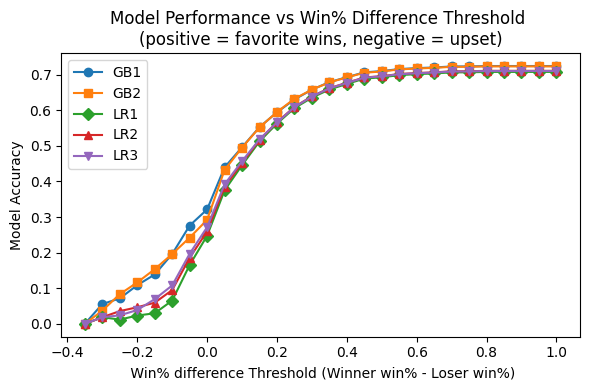

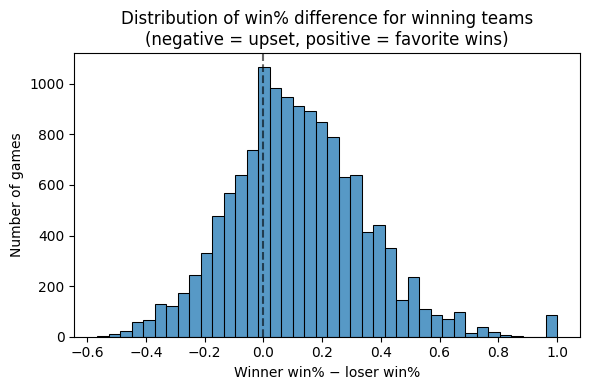

In [190]:
def count_higher_wp_losses(y_true, X_for_condition, preds_dict, loss_diff = 0.0):
    """
    y_true: 1D array/Series of true win (1)/loss (0)
    X_for_condition: DataFrame with 'diff_win_percentage' for the test rows
    preds_dict: dict[name -> 1D array/Series of predictions (0/1)],
                all aligned to y_true (same ordering)
    """
    y_true = np.ravel(y_true)

    # Condition: team had higher win % (diff > 0) but actually lost (y==0)
    mask_high_wp_lost = (X_for_condition["diff_win_percentage"] > loss_diff) & (y_true == 0)

    results = {}
    total_upsets = int(mask_high_wp_lost.sum())

    for name, y_pred in preds_dict.items():
        y_pred = np.ravel(y_pred)
        correct_loss = int((mask_high_wp_lost & (y_pred == 0)).sum())
        incorrect_loss = int((mask_high_wp_lost & (y_pred == 1)).sum())
        results[name] = {
            "total_higher_wp_losses": total_upsets,
            "correct_loss_preds": correct_loss,
            "incorrect_loss_preds": incorrect_loss,
            "pct_correct_on_these": correct_loss / total_upsets if total_upsets > 0 else np.nan,
        }

    return pd.DataFrame(results).T

preds = {
"LR1": log_reg_clf.predict(X_test_mf),
"LR3": pls.predict(X_test),
"LR2": pca.predict(X_test),
"GB2": model_top.predict(X_test_top),
"GB1": model.predict(X_test),
}

loss_diffs = np.arange(-1, 0.4, 0.05)
# loss_diffs = np.arange(0, 0.405, 0.05)

rows = []
for loss_diff in loss_diffs:
    stats = count_higher_wp_losses(y_test, X_test, preds, loss_diff=loss_diff)
    stats = stats.reset_index().rename(columns={"index": "model"})
    stats["loss_diff"] = loss_diff
    rows.append(stats)

upset_stats_df = pd.concat(rows, ignore_index=True)
# print(upset_stats_df)

# Plot: pct_correct_on_these vs loss_diff, one line per model
markers = ["o", "s", "D", "^", "v", "P", "X"]

fig, ax = plt.subplots(figsize=(6, 4))
for (model_name, sub), marker in zip(upset_stats_df.groupby("model"), markers):
    ax.plot(
        -sub["loss_diff"],
        sub["pct_correct_on_these"],
        marker=marker,
        label=model_name,
    )

ax.set_xlabel(" Win% difference Threshold (Winner win% - Loser win%)")
ax.set_ylabel("Model Accuracy")
ax.set_title(f"Model Performance vs Win% Difference Threshold \n(positive = favorite wins, negative = upset)")
ax.legend()
plt.tight_layout()
plt.savefig(_plots_dir / "model_comparison_on_win_difference_threshold_-1_to_0.4.png", transparent=True, dpi=300)
plt.show()

# Plot the distribution of win% difference for winning teams
# team - opponent win percentage from the dataframe
diff = box_score_df["diff_win_percentage"].to_numpy()
y = box_score_df["win"].astype(int).to_numpy()  # 1 = this team won, 0 = lost

# For each game row, convert to (winner win% - loser win%)
# If this row is the winner, keep diff; if it’s the loser, flip the sign.
winner_diff = np.where(y == 1, diff, -diff)

plt.figure(figsize=(6, 4))
sns.histplot(winner_diff, bins=40, kde=False)
plt.axvline(0, color="k", linestyle="--", alpha=0.6)

plt.xlabel("Winner win% − loser win%")
plt.ylabel("Number of games")
plt.title("Distribution of win% difference for winning teams\n"
        "(negative = upset, positive = favorite wins)")
plt.tight_layout()
plt.show()